# 54 — Packet-Sequence Representation for Cross-Dataset VPN Detection

**Purpose:** Test whether replacing compact flow-summary statistics with
packet-sequence representations improves cross-dataset transfer performance
across ISCX-VPN-2016, USBVPN-2021, and VNAT-2024.

**Goal:** Determine whether the previously observed LODO generalization failure
is caused by:

1. Structural dataset mismatch alone, **or**
2. Instability of compact flow-level statistical features

**Output directory:** `artifacts/thesis_finalization/nb54_packet_sequence_representation/`

### Prior results (compact 21-feature baseline)
- Pooled VPN AUC: ~0.94 (XGB)
- LODO min AUC: ~0.20
- Domain fingerprinting AUC: ~0.999
- Domain adaptation (DANN/MMD/CORAL/IRM): all failed

### Hypothesis
> Packet-level sequential representations may preserve domain-invariant
> behavioural structure better than aggregated statistics, because per-packet
> timing and size patterns encode protocol behaviour directly rather than
> through domain-sensitive summary statistics.

---
**Important:** This notebook creates a *parallel* experimental branch.
It does NOT replace the existing 21-feature pipeline.

---
## Section 0 — Context and Experimental Framing

In [1]:
import sys, json, warnings, os, gc, hashlib
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, recall_score, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.15)
np.random.seed(42)

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.clean_pipeline.feature_families import SAFE_CORE_PLUS_TEMPORAL

CLEAN = ROOT / "artifacts" / "clean_pipeline"
OUT   = ROOT / "artifacts" / "thesis_finalization" / "nb54_packet_sequence_representation"
OUT.mkdir(parents=True, exist_ok=True)

FEAT_COLS = list(SAFE_CORE_PLUS_TEMPORAL)
SEED = 42; EPS = 1e-9
TIMESTAMP = datetime.now().isoformat()

def save_json(obj, name):
    p = OUT / name
    p.write_text(json.dumps(obj, indent=2, default=str), encoding="utf-8")
    print(f"  ✓ {p}")

def save_md(text, name):
    (OUT / name).write_text(text, encoding="utf-8")
    print(f"  ✓ {OUT / name}")

def save_csv(data, name):
    p = OUT / name
    (data if isinstance(data, pd.DataFrame) else pd.DataFrame(data)).to_csv(p, index=False)
    print(f"  ✓ {p}")

def save_fig(fig, name, dpi=200):
    p = OUT / name
    fig.savefig(p, dpi=dpi, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print(f"  ✓ {p}")

print(f"ROOT: {ROOT}")
print(f"OUT:  {OUT}")
print(f"Timestamp: {TIMESTAMP}")

ROOT: C:\Users\scoti\PycharmProjects\ai-vpn-firewall
OUT:  C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb54_packet_sequence_representation
Timestamp: 2026-04-05T04:10:43.525101


In [2]:
# ── Context document ─────────────────────────────────────────────────
context_md = """# NB54 — Packet-Sequence Experiment Context

## Prior baseline
- Compact 21 flow-summary statistics (`safe_core_plus_temporal`)
- Those features showed strong domain fingerprinting (domain AUC ≈ 0.999)
- LODO transfer collapsed (min AUC ≈ 0.20)
- Domain adaptation methods (DANN, MMD, CORAL, IRM) all failed (NB51/NB52)
- Sign-reversal effects observed across datasets (NB50/NB53): ≥16/21 features reverse

## Hypothesis
Packet-level sequential representations may preserve domain-invariant behavioural
structure better than aggregated statistics because:
- Per-packet timing/size patterns encode protocol behaviour directly
- Aggregation (mean, std, percentiles) may amplify dataset-specific artefacts
- Sequence models can learn temporal motifs that generalise across capture setups

## Experimental design
- Load raw packet-level data (sizes, timestamps, directions) from all 3 datasets
- Construct fixed-length padded/truncated sequences at multiple lengths
- Train sequence classifiers (CNN, LSTM, flattened MLP)
- Evaluate pooled and LODO transfer
- Compare domain fingerprinting against 21-feature baseline
- Ablate feature channels to identify which signal drives transfer

## What this notebook does NOT do
- Replace the existing 21-feature pipeline
- Claim sequence models are a complete solution
- Ignore structural dataset mismatch
"""
save_md(context_md, "packet_sequence_experiment_context.md")
print("Context document saved.")

  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb54_packet_sequence_representation\packet_sequence_experiment_context.md
Context document saved.


---
## Section 1 — Load Packet-Level Data

Load raw packet-level sequences (sizes, timestamps, directions) from:
- VNAT: `data/processed/vnat/flows.parquet` — has raw arrays
- ISCX: `data/processed/iscx/flows.parquet` — has raw arrays
- USBVPN: `data/raw/usbvpn/` — parsed from JSON via streaming parser

For USBVPN, which lacks pre-built packet arrays in the processed parquet,
we re-parse from the raw JSON files using the existing streaming parser.

In [3]:
# ── Load VNAT and ISCX from processed flows (they have raw arrays) ───
all_flows = []

for ds_name, parquet_path in [
    ("vnat", ROOT / "data" / "processed" / "vnat" / "flows.parquet"),
    ("iscx", ROOT / "data" / "processed" / "iscx" / "flows.parquet"),
]:
    if not parquet_path.exists():
        print(f"⚠ {ds_name} flows.parquet not found at {parquet_path}")
        continue
    df_raw = pd.read_parquet(parquet_path)
    print(f"{ds_name}: loaded {len(df_raw)} flows, columns: {list(df_raw.columns)[:8]}...")

    for _, row in df_raw.iterrows():
        ts = np.asarray(row["timestamps"], dtype=np.float64)
        sz = np.asarray(row["sizes"], dtype=np.float64)
        dr = np.asarray(row["directions"], dtype=np.int64)
        if len(ts) < 3:
            continue
        # Sort by timestamp
        order = np.argsort(ts)
        ts = ts[order]; sz = np.abs(sz[order]); dr = dr[order]
        all_flows.append({
            "flow_id": row.get("flow_id", row.get("row_id", "")),
            "capture_id": row.get("capture_id", ""),
            "dataset": ds_name,
            "label": int(row["label"]),
            "sizes": sz,
            "timestamps": ts,
            "directions": dr,
            "n_packets": len(ts),
        })
    del df_raw; gc.collect()

print(f"Loaded {len(all_flows)} flows from VNAT + ISCX")

vnat: loaded 33711 flows, columns: ['capture_id', 'capture_name', 'row_id', 'flow_id', 'flow_key', 'connection_str', 'timestamps', 'sizes']...
iscx: loaded 76687 flows, columns: ['capture_id', 'capture_name', 'row_id', 'flow_id', 'flow_key', 'connection_str', 'timestamps', 'sizes']...
Loaded 19908 flows from VNAT + ISCX


In [4]:
# ── Load USBVPN from raw JSON using streaming parser ─────────────────
usbvpn_raw = ROOT / "data" / "raw" / "usbvpn"
usbvpn_feat = pd.read_parquet(CLEAN / "features.parquet")
usbvpn_feat = usbvpn_feat[usbvpn_feat["dataset"] == "usbvpn"]
usbvpn_flow_ids = set(usbvpn_feat["flow_id"].values)
usbvpn_labels = dict(zip(usbvpn_feat["flow_id"], usbvpn_feat["label"]))
usbvpn_splits = dict(zip(usbvpn_feat["flow_id"], usbvpn_feat["split"]))
usbvpn_captures = dict(zip(usbvpn_feat["flow_id"], usbvpn_feat["capture_id"]))
del usbvpn_feat; gc.collect()

usbvpn_count = 0
json_files = []
for sub in ["vpn", "nonvpn"]:
    sub_dir = usbvpn_raw / sub
    if sub_dir.is_dir():
        for item in sub_dir.rglob("*.json"):
            json_files.append((item, 1 if sub == "vpn" else 0))
    else:
        # Files directly in the subdir
        for item in (usbvpn_raw / sub).parent.glob(f"{sub}*.json"):
            json_files.append((item, 1 if "vpn" in sub else 0))

# Also check for flat files
for item in usbvpn_raw.glob("*.json"):
    label_guess = 1 if "vpn" in item.stem.lower() else 0
    json_files.append((item, label_guess))

print(f"Found {len(json_files)} USBVPN JSON files to parse")

for json_path, default_label in json_files:
    try:
        data = json.loads(json_path.read_text(encoding="utf-8"))
        if not isinstance(data, list):
            data = [data]
        for flow_dict in data:
            x_packets = flow_dict.get("x_packets", [])
            if len(x_packets) < 3:
                continue
            timestamps = []
            sizes = []
            directions = []
            for pkt in x_packets:
                raw_bytes = int(pkt.get("bytes", "0"))
                ts_str = pkt.get("timestamp_start", "")
                try:
                    from datetime import datetime as _dt
                    ts_val = _dt.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f").timestamp()
                except:
                    try:
                        ts_val = float(ts_str)
                    except:
                        ts_val = 0.0
                timestamps.append(ts_val)
                sizes.append(abs(raw_bytes))
                directions.append(1 if raw_bytes >= 0 else 0)

            if len(timestamps) < 3:
                continue

            ts = np.asarray(timestamps, dtype=np.float64)
            sz = np.asarray(sizes, dtype=np.float64)
            dr = np.asarray(directions, dtype=np.int64)
            order = np.argsort(ts)
            ts = ts[order]; sz = sz[order]; dr = dr[order]

            fid = f"usbvpn::{json_path.stem}::{usbvpn_count}"
            all_flows.append({
                "flow_id": fid,
                "capture_id": json_path.stem,
                "dataset": "usbvpn",
                "label": default_label,
                "sizes": sz, "timestamps": ts, "directions": dr,
                "n_packets": len(ts),
            })
            usbvpn_count += 1
    except Exception as e:
        print(f"  ⚠ Error parsing {json_path.name}: {e}")
        continue

print(f"USBVPN: parsed {usbvpn_count} flows from raw JSON")
print(f"Total flows: {len(all_flows)}")

# Summary
flow_meta = pd.DataFrame([{
    "flow_id": f["flow_id"], "dataset": f["dataset"],
    "label": f["label"], "n_packets": f["n_packets"],
} for f in all_flows])
for ds in sorted(flow_meta["dataset"].unique()):
    sub = flow_meta[flow_meta["dataset"] == ds]
    lbl = sub["label"].value_counts().to_dict()
    pkt_stats = sub["n_packets"].describe()
    print(f"  {ds}: {len(sub)} flows, labels={lbl}, "
          f"packets: mean={pkt_stats['mean']:.0f}, median={pkt_stats['50%']:.0f}, "
          f"max={pkt_stats['max']:.0f}")

Found 35 USBVPN JSON files to parse
USBVPN: parsed 52704 flows from raw JSON
Total flows: 72612
  iscx: 11801 flows, labels={0: 8858, 1: 2943}, packets: mean=24, median=8, max=100
  usbvpn: 52704 flows, labels={0: 44248, 1: 8456}, packets: mean=1592, median=30, max=100514
  vnat: 8107 flows, labels={0: 7733, 1: 374}, packets: mean=26, median=4, max=100


In [5]:
# ── Sequence length distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Packet-Sequence Length Distribution per Dataset",
             fontsize=14, fontweight="bold")

for ax, ds in zip(axes, sorted(flow_meta["dataset"].unique())):
    sub = flow_meta[flow_meta["dataset"] == ds]
    ax.hist(sub["n_packets"].clip(0, 500), bins=80, alpha=0.7, edgecolor="k", lw=0.3)
    ax.set_title(f"{ds.upper()} (n={len(sub):,})")
    ax.set_xlabel("Packets per flow"); ax.set_ylabel("Count")
    for thr in [10, 20, 50, 100]:
        pct = (sub["n_packets"] >= thr).mean() * 100
        ax.axvline(thr, ls="--", color="red", alpha=0.4)
        ax.text(thr + 2, ax.get_ylim()[1] * 0.9, f"{thr}p\n{pct:.0f}%",
                fontsize=7, color="red")

plt.tight_layout()
save_fig(fig, "sequence_length_distribution.png")
print("Sequence length distribution saved.")

  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb54_packet_sequence_representation\sequence_length_distribution.png
Sequence length distribution saved.


---
## Section 2 — Build Packet-Sequence Feature Tensors

Construct tensor representations at multiple sequence lengths.

**Channels:** packet_length, direction, inter-arrival time, signed_length, log_iat

**Shape:** `N_flows × sequence_length × n_channels`

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SEQ_LENGTHS = [10, 20, 50, 100]

def build_sequence_tensor(flows, seq_len, channels="all"):
    """
    Build padded/truncated sequence tensors.

    channels: 'all' | 'length' | 'direction' | 'iat' | 'length_dir' | 'length_iat' | 'dir_iat'

    Returns: X (N, seq_len, n_channels), y (N,), d (N,), flow_ids list
    """
    N = len(flows)
    le_ds = LabelEncoder()
    datasets = [f["dataset"] for f in flows]
    le_ds.fit(sorted(set(datasets)))

    # Determine channel count
    chan_map = {
        "all": 5,        # len, dir, iat, signed_len, log_iat
        "length": 1,
        "direction": 1,
        "iat": 1,
        "length_dir": 2,
        "length_iat": 2,
        "dir_iat": 2,
    }
    n_ch = chan_map.get(channels, 5)
    X = np.zeros((N, seq_len, n_ch), dtype=np.float32)
    y = np.zeros(N, dtype=np.float32)
    d = np.zeros(N, dtype=np.int64)
    fids = []

    for i, flow in enumerate(flows):
        sz = flow["sizes"][:seq_len]
        dr = flow["directions"][:seq_len]
        ts = flow["timestamps"][:seq_len]
        n = len(sz)

        # IAT
        iat = np.zeros(n, dtype=np.float64)
        if n > 1:
            iat[1:] = np.diff(ts)
            iat = np.clip(iat, 0, 60)  # clip extreme IATs

        signed_len = sz * (2 * dr - 1)  # +len for dir=1, -len for dir=0
        log_iat = np.log1p(iat)

        if channels == "all":
            X[i, :n, 0] = sz
            X[i, :n, 1] = dr
            X[i, :n, 2] = iat
            X[i, :n, 3] = signed_len
            X[i, :n, 4] = log_iat
        elif channels == "length":
            X[i, :n, 0] = sz
        elif channels == "direction":
            X[i, :n, 0] = dr
        elif channels == "iat":
            X[i, :n, 0] = iat
        elif channels == "length_dir":
            X[i, :n, 0] = sz
            X[i, :n, 1] = dr
        elif channels == "length_iat":
            X[i, :n, 0] = sz
            X[i, :n, 1] = iat
        elif channels == "dir_iat":
            X[i, :n, 0] = dr
            X[i, :n, 1] = iat

        y[i] = flow["label"]
        d[i] = le_ds.transform([flow["dataset"]])[0]
        fids.append(flow["flow_id"])

    return X, y, d, fids, le_ds

# Normalise each channel to zero mean, unit variance (fit on all data)
def normalise_channels(X_train, X_test):
    """Per-channel normalisation. Returns copies."""
    X_tr = X_train.copy(); X_te = X_test.copy()
    for ch in range(X_tr.shape[2]):
        vals = X_tr[:, :, ch]
        nonzero = vals[vals != 0]
        if len(nonzero) > 0:
            mu = nonzero.mean(); sd = nonzero.std() + EPS
        else:
            mu = 0; sd = 1
        X_tr[:, :, ch] = (X_tr[:, :, ch] - mu) / sd
        X_te[:, :, ch] = (X_te[:, :, ch] - mu) / sd
    return X_tr, X_te

# Build tensors for default length (50)
DEFAULT_SEQ = 50
X_all, y_all, d_all, fids_all, le_ds = build_sequence_tensor(all_flows, DEFAULT_SEQ, "all")
print(f"Sequence tensor: {X_all.shape} ({X_all.nbytes / 1e6:.1f} MB)")
print(f"Labels: {np.bincount(y_all.astype(int))}")
print(f"Domains: {np.bincount(d_all)}")
print(f"Channels: [pkt_len, direction, iat, signed_len, log_iat]")

# Save metadata
tensor_meta = {
    "shape": list(X_all.shape),
    "channels": ["packet_length", "direction", "inter_arrival_time",
                  "signed_length", "log_iat"],
    "sequence_length": DEFAULT_SEQ,
    "n_flows": int(len(all_flows)),
    "datasets": list(le_ds.classes_),
    "label_counts": {int(k): int(v) for k, v in zip(*np.unique(y_all, return_counts=True))},
    "domain_counts": {le_ds.classes_[int(k)]: int(v) for k, v in zip(*np.unique(d_all, return_counts=True))},
    "timestamp": TIMESTAMP,
}
save_json(tensor_meta, "sequence_tensor_metadata.json")

Device: cpu
Sequence tensor: (72612, 50, 5) (72.6 MB)
Labels: [60839 11773]
Domains: [11801 52704  8107]
Channels: [pkt_len, direction, iat, signed_len, log_iat]
  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb54_packet_sequence_representation\sequence_tensor_metadata.json


In [7]:
# ── Create train / test splits ───────────────────────────────────────
# Use features.parquet split assignments where available, otherwise random
feat_df = pd.read_parquet(CLEAN / "features.parquet")
split_map = dict(zip(feat_df["flow_id"], feat_df["split"]))
del feat_df; gc.collect()

def assign_splits(flows, fids, d_all):
    """Assign train/val/test splits matching the clean pipeline where possible."""
    splits = np.array(["train"] * len(fids), dtype=object)
    matched = 0
    for i, fid in enumerate(fids):
        sp = split_map.get(fid, None)
        if sp is not None:
            splits[i] = sp
            matched += 1
        else:
            # Random fallback: 70/15/15
            r = np.random.random()
            if r < 0.70:
                splits[i] = "train"
            elif r < 0.85:
                splits[i] = "val"
            else:
                splits[i] = "test"
    print(f"  Split assignment: {matched}/{len(fids)} matched from clean pipeline")
    return splits

flow_splits = assign_splits(all_flows, fids_all, d_all)
train_mask = flow_splits == "train"
val_mask   = flow_splits == "val"
test_mask  = flow_splits == "test"
print(f"Train: {train_mask.sum()}, Val: {val_mask.sum()}, Test: {test_mask.sum()}")

  Split assignment: 0/72612 matched from clean pipeline
Train: 50940, Val: 10866, Test: 10806


---
## Section 3 — Baseline Sequence Classifiers

Train three architectures:
1. **Shallow 1D-CNN** — captures local n-gram patterns
2. **Bidirectional LSTM** — captures temporal dependencies
3. **Temporal MLP** — flattened baseline (no sequential inductive bias)

Each evaluated pooled and LODO.

In [8]:
# ── Model definitions ────────────────────────────────────────────────

class SeqCNN(nn.Module):
    """Shallow 1D-CNN for packet sequences."""
    def __init__(self, n_channels, seq_len, n_filters=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_channels, n_filters, kernel_size=3, padding=1),
            nn.ReLU(), nn.BatchNorm1d(n_filters),
            nn.Conv1d(n_filters, n_filters, kernel_size=3, padding=1),
            nn.ReLU(), nn.BatchNorm1d(n_filters),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Sequential(
            nn.Linear(n_filters, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1), nn.Sigmoid(),
        )
        self.encoder_dim = n_filters

    def encode(self, x):
        # x: (B, seq_len, channels) -> (B, channels, seq_len) for Conv1d
        x = x.transpose(1, 2)
        return self.conv(x).squeeze(-1)

    def forward(self, x):
        return self.head(self.encode(x)).squeeze(-1)


class SeqLSTM(nn.Module):
    """Bidirectional LSTM for packet sequences."""
    def __init__(self, n_channels, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(n_channels, hidden, batch_first=True,
                            bidirectional=True, num_layers=1, dropout=0.0)
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1), nn.Sigmoid(),
        )
        self.encoder_dim = hidden * 2

    def encode(self, x):
        out, (hn, _) = self.lstm(x)
        # Concat final hidden states from both directions
        return torch.cat([hn[0], hn[1]], dim=1)

    def forward(self, x):
        return self.head(self.encode(x)).squeeze(-1)


class SeqMLP(nn.Module):
    """Flattened temporal MLP — no sequential inductive bias."""
    def __init__(self, n_channels, seq_len, hidden=128):
        super().__init__()
        self.flat_dim = n_channels * seq_len
        self.encoder = nn.Sequential(
            nn.Linear(self.flat_dim, hidden), nn.ReLU(),
            nn.BatchNorm1d(hidden), nn.Dropout(0.3),
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.Linear(hidden // 2, 1), nn.Sigmoid(),
        )
        self.encoder_dim = hidden // 2

    def encode(self, x):
        return self.encoder(x.reshape(x.size(0), -1))

    def forward(self, x):
        return self.head(self.encode(x)).squeeze(-1)


print("Model architectures defined: SeqCNN, SeqLSTM, SeqMLP")

Model architectures defined: SeqCNN, SeqLSTM, SeqMLP


In [9]:
# ── Training and evaluation infrastructure ───────────────────────────

def train_seq_model(model, X_tr, y_tr, X_val, y_val, epochs=60, lr=1e-3, batch_size=256):
    """Train a sequence model and return training history."""
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    bce = nn.BCELoss()
    ds = TensorDataset(torch.FloatTensor(X_tr).to(device),
                       torch.FloatTensor(y_tr).to(device))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)
    best_auc = 0; best_state = None; history = []

    for epoch in range(epochs):
        model.train()
        ep_loss = 0; nb = 0
        for xb, yb in loader:
            pred = model(xb)
            loss = bce(pred, yb)
            opt.zero_grad(); loss.backward(); opt.step()
            ep_loss += loss.item(); nb += 1

        # Validation AUC
        val_auc = np.nan
        if len(X_val) > 0 and len(np.unique(y_val)) == 2:
            model.eval()
            with torch.no_grad():
                val_pred = model(torch.FloatTensor(X_val).to(device)).cpu().numpy()
            val_auc = roc_auc_score(y_val, val_pred)
            if val_auc > best_auc:
                best_auc = val_auc
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        history.append({"epoch": epoch, "loss": ep_loss / max(nb, 1), "val_auc": val_auc})

    # Restore best
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return history

def eval_seq_model(model, X, y):
    """Evaluate AUC, recall, FPR."""
    model.eval()
    with torch.no_grad():
        preds = model(torch.FloatTensor(X).to(device)).cpu().numpy()
    results = {}
    if len(np.unique(y)) == 2:
        results["vpn_auc"] = float(roc_auc_score(y, preds))
        y_pred = (preds >= 0.5).astype(int)
        results["recall"] = float(recall_score(y, y_pred, zero_division=0))
        # FPR = FP / (FP + TN)
        fp = ((y_pred == 1) & (y == 0)).sum()
        tn = ((y_pred == 0) & (y == 0)).sum()
        results["fpr"] = float(fp / max(fp + tn, 1))
    else:
        results["vpn_auc"] = np.nan
        results["recall"] = np.nan
        results["fpr"] = np.nan
    return results, preds

def extract_embeddings(model, X):
    """Extract encoder embeddings."""
    model.eval()
    with torch.no_grad():
        emb = model.encode(torch.FloatTensor(X).to(device)).cpu().numpy()
    return emb

def domain_auc(feats, d, feats_train=None, d_train=None):
    """Domain classifier AUC.

    If feats_train/d_train are provided, the classifier is fit on training
    data and evaluated on feats/d (test). Otherwise fits and evaluates on
    the same data (legacy fallback).
    """
    try:
        clf = LogisticRegression(max_iter=500, random_state=SEED, multi_class="ovr")
        if feats_train is not None and d_train is not None:
            clf.fit(feats_train, d_train)
        else:
            clf.fit(feats, d)
        proba = clf.predict_proba(feats)
        d_onehot = pd.get_dummies(d)
        # Align columns with clf.classes_
        d_onehot = d_onehot.reindex(columns=clf.classes_, fill_value=0)
        return float(roc_auc_score(d_onehot, proba, average="macro"))
    except:
        return np.nan

print("Training/evaluation infrastructure ready.")

Training/evaluation infrastructure ready.


In [10]:
# ── Prepare normalised data for default sequence length ──────────────
X_tr_norm, X_te_norm = normalise_channels(X_all[train_mask], X_all[test_mask])
X_val_norm = X_all[val_mask].copy()
# Apply same normalisation to val
for ch in range(X_all.shape[2]):
    vals = X_all[train_mask, :, ch]
    nonzero = vals[vals != 0]
    mu = nonzero.mean() if len(nonzero) > 0 else 0
    sd = (nonzero.std() + EPS) if len(nonzero) > 0 else 1
    X_val_norm[:, :, ch] = (X_val_norm[:, :, ch] - mu) / sd

y_tr = y_all[train_mask]; y_te = y_all[test_mask]; y_val = y_all[val_mask]
d_tr = d_all[train_mask]; d_te = d_all[test_mask]; d_val = d_all[val_mask]
n_ch = X_all.shape[2]

print(f"Training set: {X_tr_norm.shape}, Test set: {X_te_norm.shape}, Val set: {X_val_norm.shape}")

Training set: (50940, 50, 5), Test set: (10806, 50, 5), Val set: (10866, 50, 5)


In [11]:
# ── Train all three models (pooled) ──────────────────────────────────
EPOCHS = 60
model_results = []

for ModelClass, name in [
    (lambda: SeqCNN(n_ch, DEFAULT_SEQ), "CNN"),
    (lambda: SeqLSTM(n_ch), "LSTM"),
    (lambda: SeqMLP(n_ch, DEFAULT_SEQ), "MLP"),
]:
    print(f"\nTraining {name} (pooled, seq_len={DEFAULT_SEQ})...")
    torch.manual_seed(SEED)
    model = ModelClass()
    hist = train_seq_model(model, X_tr_norm, y_tr, X_val_norm, y_val, epochs=EPOCHS)
    res_te, preds_te = eval_seq_model(model, X_te_norm, y_te)
    print(f"  Test: {res_te}")

    # LODO evaluation
    lodo_results = []
    datasets_list = sorted(set(f["dataset"] for f in all_flows))
    for test_ds_idx, test_ds in enumerate(datasets_list):
        ds_idx = list(le_ds.classes_).index(test_ds)
        lodo_tr_mask = train_mask & (d_all != ds_idx)
        lodo_te_mask = (d_all == ds_idx)

        if lodo_tr_mask.sum() < 10 or lodo_te_mask.sum() < 10:
            continue
        if len(np.unique(y_all[lodo_tr_mask])) < 2:
            continue

        X_ltr, X_lte = normalise_channels(X_all[lodo_tr_mask], X_all[lodo_te_mask])
        # Val from training domains
        lodo_val_mask = val_mask & (d_all != ds_idx)
        X_lval = X_all[lodo_val_mask].copy()
        for ch_i in range(n_ch):
            vals = X_all[lodo_tr_mask, :, ch_i]
            nz = vals[vals != 0]
            mu = nz.mean() if len(nz) > 0 else 0
            sd = (nz.std() + EPS) if len(nz) > 0 else 1
            X_lval[:, :, ch_i] = (X_lval[:, :, ch_i] - mu) / sd

        torch.manual_seed(SEED)
        lodo_model = ModelClass()
        train_seq_model(lodo_model, X_ltr, y_all[lodo_tr_mask],
                        X_lval, y_all[lodo_val_mask], epochs=EPOCHS)
        lodo_res, _ = eval_seq_model(lodo_model, X_lte, y_all[lodo_te_mask])
        lodo_results.append({"held_out": test_ds, **lodo_res})
        print(f"  LODO {test_ds}: vpn_auc={lodo_res['vpn_auc']:.4f}")

    lodo_df = pd.DataFrame(lodo_results)
    lodo_min = lodo_df["vpn_auc"].min() if len(lodo_df) > 0 else np.nan
    lodo_mean = lodo_df["vpn_auc"].mean() if len(lodo_df) > 0 else np.nan
    worst_recall = lodo_df["recall"].min() if len(lodo_df) > 0 and "recall" in lodo_df else np.nan
    worst_fpr = lodo_df["fpr"].max() if len(lodo_df) > 0 and "fpr" in lodo_df else np.nan

    model_results.append({
        "model": name, "seq_len": DEFAULT_SEQ, "channels": "all",
        "pooled_vpn_auc": res_te["vpn_auc"],
        "lodo_min_auc": lodo_min, "lodo_mean_auc": lodo_mean,
        "worst_recall": worst_recall, "worst_fpr": worst_fpr,
    })

    # Store model for later sections
    globals()[f"model_{name.lower()}"] = model

results_df = pd.DataFrame(model_results)
print("\n=== Sequence Model Results ===")
print(results_df.to_string(index=False))
save_csv(results_df, "sequence_model_results.csv")


Training CNN (pooled, seq_len=50)...
  Test: {'vpn_auc': 0.9775454860218435, 'recall': 0.7932992617830777, 'fpr': 0.012493090105030403}
  LODO iscx: vpn_auc=0.5897
  LODO usbvpn: vpn_auc=0.5494
  LODO vnat: vpn_auc=0.5905

Training LSTM (pooled, seq_len=50)...
  Test: {'vpn_auc': 0.988492486146465, 'recall': 0.8472458830210108, 'fpr': 0.015588723051409618}
  LODO iscx: vpn_auc=0.6217
  LODO usbvpn: vpn_auc=0.4587
  LODO vnat: vpn_auc=0.2775

Training MLP (pooled, seq_len=50)...
  Test: {'vpn_auc': 0.9592212136365306, 'recall': 0.6609880749574105, 'fpr': 0.024654505251520176}
  LODO iscx: vpn_auc=0.5001
  LODO usbvpn: vpn_auc=0.5457
  LODO vnat: vpn_auc=0.5278

=== Sequence Model Results ===
model  seq_len channels  pooled_vpn_auc  lodo_min_auc  lodo_mean_auc  worst_recall  worst_fpr
  CNN       50      all        0.977545      0.549420       0.576534      0.098628   0.140437
 LSTM       50      all        0.988492      0.277468       0.452611      0.069519   0.206776
  MLP       50   

### Interpretation — Baseline Sequence Classifiers

Compare pooled AUC and LODO min AUC against the 21-feature baseline.
If LODO transfer improves, sequence representations may preserve more
domain-invariant signal. If not, the mismatch is structural.

---
## Section 4 — Domain Fingerprinting Test in Sequence Space

Train domain classifier on raw sequence representation and compare
against the 21-feature baseline domain AUC (~0.999).

In [12]:
# ── Domain fingerprinting on raw sequences ───────────────────────────
# Flatten sequence for logistic regression domain classifier
X_te_flat = X_te_norm.reshape(X_te_norm.shape[0], -1)
raw_seq_domain_auc = domain_auc(X_te_flat, d_te)

# Domain AUC on 21-feature baseline
feat_baseline = pd.read_parquet(CLEAN / "features.parquet")
scaler = StandardScaler()
X_bl_all = scaler.fit_transform(feat_baseline[FEAT_COLS].values)
bl_test_mask = (feat_baseline["split"] == "test").values
X_bl_te = X_bl_all[bl_test_mask]
d_bl_te = LabelEncoder().fit_transform(feat_baseline.loc[bl_test_mask, "dataset"])
baseline_domain_auc = domain_auc(X_bl_te, d_bl_te)
del feat_baseline, X_bl_all; gc.collect()

fingerprint_results = [
    {"representation": "21-feature flow statistics", "domain_auc": baseline_domain_auc},
    {"representation": f"raw sequence (len={DEFAULT_SEQ}, flattened)", "domain_auc": raw_seq_domain_auc},
]

print("=== Domain Fingerprinting ===")
for r in fingerprint_results:
    print(f"  {r['representation']}: domain AUC = {r['domain_auc']:.4f}")

fp_df = pd.DataFrame(fingerprint_results)
save_csv(fp_df, "sequence_domain_fingerprint_auc.csv")

=== Domain Fingerprinting ===
  21-feature flow statistics: domain AUC = nan
  raw sequence (len=50, flattened): domain AUC = nan
  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb54_packet_sequence_representation\sequence_domain_fingerprint_auc.csv


### Interpretation — Domain Fingerprinting

If the raw sequence domain AUC is substantially lower than 0.999,
packet sequences may carry less dataset-specific signature.
If still near 1.0, the domain fingerprint is embedded at the packet level too.

---
## Section 5 — Latent Representation Invariance Test

Extract encoder outputs from CNN and LSTM models, then measure
domain separability of the learned latent space.

In [13]:
# ── Latent domain AUC (train-fitted, evaluated on test) ──────────────
from sklearn.model_selection import GroupKFold

latent_results = []

# Train embeddings for domain clf fitting
for name in ["cnn", "lstm", "mlp"]:
    model = globals().get(f"model_{name}")
    if model is None:
        continue
    emb_te = extract_embeddings(model, X_te_norm)
    emb_tr = extract_embeddings(model, X_tr_norm)
    lat_dauc = domain_auc(emb_te, d_te, feats_train=emb_tr, d_train=d_tr)
    latent_results.append({
        "model": name.upper(),
        "representation": "encoder_latent",
        "domain_auc": lat_dauc,
    })
    print(f"  {name.upper()} latent domain AUC (train→test): {lat_dauc:.4f}")

# Add raw baselines
latent_results.insert(0, {"model": "RAW", "representation": "raw_sequence_flat",
                           "domain_auc": raw_seq_domain_auc})
latent_results.insert(0, {"model": "BASELINE", "representation": "21_feature_stats",
                           "domain_auc": baseline_domain_auc})

lat_df = pd.DataFrame(latent_results)
print("\n=== Latent Representation Domain AUC ===")
print(lat_df.to_string(index=False))
save_csv(lat_df, "latent_sequence_domain_auc.csv")

# ── Capture-safe GroupKFold domain AUC for sequence embeddings ───────
print("\n=== Capture-safe domain AUC (GroupKFold on capture_id) ===")
# Build capture_id array aligned to the flow order
capture_ids = np.array([f.get("capture_id", f.get("flow_id", "")) for f in all_flows])
capture_safe_rows = []
for name in ["cnn", "lstm", "mlp"]:
    model = globals().get(f"model_{name}")
    if model is None:
        continue
    # Use test embeddings and test capture IDs
    emb_all_model = extract_embeddings(model, X_te_norm)
    d_all_model = d_te
    cap_all_model = capture_ids[test_mask]

    # GroupKFold: no capture in both train and test
    unique_caps = np.unique(cap_all_model)
    if len(unique_caps) >= 5:
        gkf = GroupKFold(n_splits=min(5, len(unique_caps)))
        fold_aucs = []
        for fold_i, (tr_idx, te_idx) in enumerate(gkf.split(emb_all_model, d_all_model, groups=cap_all_model)):
            if len(np.unique(d_all_model[tr_idx])) < 2 or len(np.unique(d_all_model[te_idx])) < 2:
                continue
            fold_clf = LogisticRegression(max_iter=500, random_state=SEED, multi_class="ovr")
            fold_clf.fit(emb_all_model[tr_idx], d_all_model[tr_idx])
            fold_proba = fold_clf.predict_proba(emb_all_model[te_idx])
            d_te_oh = pd.get_dummies(d_all_model[te_idx]).reindex(columns=fold_clf.classes_, fill_value=0)
            try:
                fauc = float(roc_auc_score(d_te_oh, fold_proba, average="macro"))
                fold_aucs.append(fauc)
            except:
                pass
        mean_cap_auc = np.mean(fold_aucs) if fold_aucs else np.nan
        std_cap_auc = np.std(fold_aucs) if fold_aucs else np.nan
    else:
        mean_cap_auc = np.nan; std_cap_auc = np.nan

    capture_safe_rows.append({
        "model": name.upper(),
        "capture_safe_domain_auc_mean": mean_cap_auc,
        "capture_safe_domain_auc_std": std_cap_auc,
    })
    print(f"  {name.upper()} capture-safe domain AUC: {mean_cap_auc:.4f} ± {std_cap_auc:.4f}" if not np.isnan(mean_cap_auc) else f"  {name.upper()}: insufficient captures for GroupKFold")

cap_safe_df = pd.DataFrame(capture_safe_rows)
save_csv(cap_safe_df, "capture_safe_sequence_domain_auc.csv")

  CNN latent domain AUC: nan
  LSTM latent domain AUC: nan
  MLP latent domain AUC: nan

=== Latent Representation Domain AUC ===
   model    representation  domain_auc
BASELINE  21_feature_stats         NaN
     RAW raw_sequence_flat         NaN
     CNN    encoder_latent         NaN
    LSTM    encoder_latent         NaN
     MLP    encoder_latent         NaN
  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb54_packet_sequence_representation\latent_sequence_domain_auc.csv


---
## Section 6 — Cross-Dataset Transfer Comparison vs Flow-Statistics Baseline

Direct comparison table across all representations.

In [14]:
# ── Build comparison table ───────────────────────────────────────────
# Load NB51 results for baseline
nb51_path = ROOT / "artifacts" / "thesis_finalization" / "nb51_modern_domain_adaptation" / "modern_domain_adaptation_results.csv"
nb51_results = None
if nb51_path.exists():
    nb51_results = pd.read_csv(nb51_path)

# Flow-statistics baseline (approximate from clean pipeline known results)
# Use NB51 or known values
baseline_pooled_auc = 0.94   # approximate XGB baseline
baseline_lodo_min = 0.20     # approximate from prior experiments

comparison_rows = [
    {"representation": "flow_statistics_21feat",
     "model": "XGB (baseline)",
     "pooled_auc": baseline_pooled_auc,
     "lodo_min_auc": baseline_lodo_min,
     "domain_auc": baseline_domain_auc},
]

for _, row in results_df.iterrows():
    # Find corresponding latent domain AUC
    lat_match = lat_df[lat_df["model"] == row["model"]]
    lat_d = lat_match["domain_auc"].values[0] if len(lat_match) > 0 else np.nan
    comparison_rows.append({
        "representation": f"packet_sequence_{row['seq_len']}",
        "model": row["model"],
        "pooled_auc": row["pooled_vpn_auc"],
        "lodo_min_auc": row["lodo_min_auc"],
        "domain_auc": lat_d,
    })

comp_df = pd.DataFrame(comparison_rows)
print("=== Cross-Dataset Transfer Comparison ===")
print(comp_df.to_string(index=False))
save_csv(comp_df, "representation_transfer_comparison.csv")

=== Cross-Dataset Transfer Comparison ===
        representation          model  pooled_auc  lodo_min_auc  domain_auc
flow_statistics_21feat XGB (baseline)    0.940000      0.200000         NaN
    packet_sequence_50            CNN    0.977545      0.549420         NaN
    packet_sequence_50           LSTM    0.988492      0.277468         NaN
    packet_sequence_50            MLP    0.959221      0.500097         NaN
  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb54_packet_sequence_representation\representation_transfer_comparison.csv


---
## Section 7 — Sequence-Length Sensitivity Analysis

Repeat experiments for sequence lengths: 10, 20, 50, 100.
Measure how LODO transfer and domain fingerprinting scale with sequence length.

In [15]:
# ── Sequence length sweep ────────────────────────────────────────────
length_sweep = []

for seq_len in SEQ_LENGTHS:
    print(f"\n--- Sequence length = {seq_len} ---")
    X_sl, y_sl, d_sl, _, _ = build_sequence_tensor(all_flows, seq_len, "all")

    # Normalise
    X_sl_tr, X_sl_te = normalise_channels(X_sl[train_mask], X_sl[test_mask])

    # Val
    X_sl_val = X_sl[val_mask].copy()
    for ch_i in range(X_sl.shape[2]):
        vals = X_sl[train_mask, :, ch_i]
        nz = vals[vals != 0]
        mu = nz.mean() if len(nz) > 0 else 0
        sd = (nz.std() + EPS) if len(nz) > 0 else 1
        X_sl_val[:, :, ch_i] = (X_sl_val[:, :, ch_i] - mu) / sd

    n_ch_sl = X_sl.shape[2]

    # Train CNN (representative model)
    torch.manual_seed(SEED)
    cnn = SeqCNN(n_ch_sl, seq_len)
    train_seq_model(cnn, X_sl_tr, y_tr, X_sl_val, y_val, epochs=50)
    res_te, _ = eval_seq_model(cnn, X_sl_te, y_te)

    # Domain AUC on raw flattened
    flat_te = X_sl_te.reshape(X_sl_te.shape[0], -1)
    raw_dauc = domain_auc(flat_te, d_te)

    # Latent domain AUC
    lat_emb = extract_embeddings(cnn, X_sl_te)
    lat_dauc = domain_auc(lat_emb, d_te)

    # LODO
    datasets_list = sorted(set(f["dataset"] for f in all_flows))
    lodo_aucs = []
    for test_ds in datasets_list:
        ds_idx = list(le_ds.classes_).index(test_ds)
        lodo_tr = train_mask & (d_sl != ds_idx)
        lodo_te = (d_sl == ds_idx)
        if lodo_tr.sum() < 10 or lodo_te.sum() < 10:
            continue
        if len(np.unique(y_sl[lodo_tr])) < 2:
            continue
        X_ltr, X_lte = normalise_channels(X_sl[lodo_tr], X_sl[lodo_te])
        # Val
        lv = val_mask & (d_sl != ds_idx)
        Xlv = X_sl[lv].copy()
        for ch_i in range(n_ch_sl):
            vals = X_sl[lodo_tr, :, ch_i]
            nz = vals[vals != 0]
            mu = nz.mean() if len(nz) > 0 else 0
            sd = (nz.std() + EPS) if len(nz) > 0 else 1
            Xlv[:, :, ch_i] = (Xlv[:, :, ch_i] - mu) / sd
        torch.manual_seed(SEED)
        lodo_cnn = SeqCNN(n_ch_sl, seq_len)
        train_seq_model(lodo_cnn, X_ltr, y_sl[lodo_tr], Xlv, y_sl[lv], epochs=50)
        lr, _ = eval_seq_model(lodo_cnn, X_lte, y_sl[lodo_te])
        lodo_aucs.append(lr["vpn_auc"])
        print(f"  LODO {test_ds}: {lr['vpn_auc']:.4f}")

    length_sweep.append({
        "seq_len": seq_len,
        "pooled_vpn_auc": res_te["vpn_auc"],
        "lodo_min_auc": min(lodo_aucs) if lodo_aucs else np.nan,
        "lodo_mean_auc": np.mean(lodo_aucs) if lodo_aucs else np.nan,
        "raw_domain_auc": raw_dauc,
        "latent_domain_auc": lat_dauc,
    })

    del X_sl, X_sl_tr, X_sl_te; gc.collect()

sweep_df = pd.DataFrame(length_sweep)
print("\n=== Sequence Length Sweep ===")
print(sweep_df.to_string(index=False))
save_csv(sweep_df, "sequence_length_sweep.csv")


--- Sequence length = 10 ---
  LODO iscx: 0.6176
  LODO usbvpn: 0.6606
  LODO vnat: 0.8326

--- Sequence length = 20 ---
  LODO iscx: 0.5820
  LODO usbvpn: 0.3800
  LODO vnat: 0.6432

--- Sequence length = 50 ---
  LODO iscx: 0.5946
  LODO usbvpn: 0.5315
  LODO vnat: 0.3207

--- Sequence length = 100 ---
  LODO iscx: 0.6046
  LODO usbvpn: 0.6157
  LODO vnat: 0.5693

=== Sequence Length Sweep ===
 seq_len  pooled_vpn_auc  lodo_min_auc  lodo_mean_auc  raw_domain_auc  latent_domain_auc
      10        0.936120      0.617570       0.703596             NaN                NaN
      20        0.973116      0.379985       0.535080             NaN                NaN
      50        0.975611      0.320733       0.482251             NaN                NaN
     100        0.978785      0.569328       0.596545             NaN                NaN


In [16]:
# ── Sequence length sensitivity plot ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Sequence-Length Sensitivity", fontsize=14, fontweight="bold")

ax = axes[0]
ax.plot(sweep_df["seq_len"], sweep_df["pooled_vpn_auc"], "o-", lw=2, label="Pooled VPN AUC")
ax.plot(sweep_df["seq_len"], sweep_df["lodo_min_auc"], "s--", lw=2, label="LODO min AUC")
ax.plot(sweep_df["seq_len"], sweep_df["lodo_mean_auc"], "^:", lw=2, label="LODO mean AUC")
ax.axhline(baseline_lodo_min, ls=":", color="gray", alpha=0.6, label=f"21-feat LODO min ({baseline_lodo_min:.2f})")
ax.set_xlabel("Sequence Length (packets)"); ax.set_ylabel("AUC")
ax.set_title("Transfer Performance vs Sequence Length"); ax.legend(fontsize=9)

ax = axes[1]
ax.plot(sweep_df["seq_len"], sweep_df["raw_domain_auc"], "o-", lw=2, label="Raw sequence domain AUC")
ax.plot(sweep_df["seq_len"], sweep_df["latent_domain_auc"], "s--", lw=2, label="Latent domain AUC")
ax.axhline(baseline_domain_auc, ls=":", color="gray", alpha=0.6, label=f"21-feat domain AUC ({baseline_domain_auc:.3f})")
ax.set_xlabel("Sequence Length (packets)"); ax.set_ylabel("Domain AUC")
ax.set_title("Domain Fingerprinting vs Sequence Length"); ax.legend(fontsize=9)

plt.tight_layout()
save_fig(fig, "sequence_length_transfer_curve.png")

  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb54_packet_sequence_representation\sequence_length_transfer_curve.png


---
## Section 8 — Feature-Channel Ablation

Train models using subsets of channels to determine which signal
contributes most to transfer robustness.

In [17]:
# ── Channel ablation ─────────────────────────────────────────────────
channel_configs = [
    ("length", "Packet length only"),
    ("direction", "Direction only"),
    ("iat", "IAT only"),
    ("length_dir", "Length + Direction"),
    ("length_iat", "Length + IAT"),
    ("dir_iat", "Direction + IAT"),
    ("all", "All channels"),
]

ablation_rows = []
for ch_name, ch_desc in channel_configs:
    print(f"\n--- Channel: {ch_desc} ({ch_name}) ---")
    X_ab, y_ab, d_ab, _, _ = build_sequence_tensor(all_flows, DEFAULT_SEQ, ch_name)
    n_ch_ab = X_ab.shape[2]

    X_ab_tr, X_ab_te = normalise_channels(X_ab[train_mask], X_ab[test_mask])
    X_ab_val = X_ab[val_mask].copy()
    for ch_i in range(n_ch_ab):
        vals = X_ab[train_mask, :, ch_i]
        nz = vals[vals != 0]
        mu = nz.mean() if len(nz) > 0 else 0
        sd = (nz.std() + EPS) if len(nz) > 0 else 1
        X_ab_val[:, :, ch_i] = (X_ab_val[:, :, ch_i] - mu) / sd

    # Train CNN
    torch.manual_seed(SEED)
    cnn_ab = SeqCNN(n_ch_ab, DEFAULT_SEQ)
    train_seq_model(cnn_ab, X_ab_tr, y_tr, X_ab_val, y_val, epochs=50)
    res_ab, _ = eval_seq_model(cnn_ab, X_ab_te, y_te)

    # LODO
    datasets_list = sorted(set(f["dataset"] for f in all_flows))
    lodo_aucs_ab = []
    for test_ds in datasets_list:
        ds_idx = list(le_ds.classes_).index(test_ds)
        lt = train_mask & (d_ab != ds_idx)
        lte = (d_ab == ds_idx)
        if lt.sum() < 10 or lte.sum() < 10: continue
        if len(np.unique(y_ab[lt])) < 2: continue
        Xlt, Xlte = normalise_channels(X_ab[lt], X_ab[lte])
        lv = val_mask & (d_ab != ds_idx)
        Xlv = X_ab[lv].copy()
        for ch_i in range(n_ch_ab):
            vals = X_ab[lt, :, ch_i]; nz = vals[vals != 0]
            mu = nz.mean() if len(nz) > 0 else 0
            sd = (nz.std() + EPS) if len(nz) > 0 else 1
            Xlv[:, :, ch_i] = (Xlv[:, :, ch_i] - mu) / sd
        torch.manual_seed(SEED)
        lcnn = SeqCNN(n_ch_ab, DEFAULT_SEQ)
        train_seq_model(lcnn, Xlt, y_ab[lt], Xlv, y_ab[lv], epochs=50)
        lr, _ = eval_seq_model(lcnn, Xlte, y_ab[lte])
        lodo_aucs_ab.append(lr["vpn_auc"])

    # Domain AUC
    flat = X_ab_te.reshape(X_ab_te.shape[0], -1)
    d_auc = domain_auc(flat, d_te)

    ablation_rows.append({
        "channels": ch_name, "description": ch_desc,
        "n_channels": n_ch_ab,
        "pooled_vpn_auc": res_ab["vpn_auc"],
        "lodo_min_auc": min(lodo_aucs_ab) if lodo_aucs_ab else np.nan,
        "lodo_mean_auc": np.mean(lodo_aucs_ab) if lodo_aucs_ab else np.nan,
        "domain_auc": d_auc,
    })
    print(f"  pooled={res_ab['vpn_auc']:.4f}, "
          f"lodo_min={min(lodo_aucs_ab) if lodo_aucs_ab else 'N/A'}, "
          f"domain_auc={d_auc:.4f}")

    del X_ab, X_ab_tr, X_ab_te; gc.collect()

ablation_df = pd.DataFrame(ablation_rows)
print("\n=== Channel Ablation ===")
print(ablation_df.to_string(index=False))
save_csv(ablation_df, "sequence_channel_ablation.csv")


--- Channel: Packet length only (length) ---
  pooled=0.9914, lodo_min=0.42337581881309905, domain_auc=nan

--- Channel: Direction only (direction) ---
  pooled=0.9234, lodo_min=0.4762576712485673, domain_auc=nan

--- Channel: IAT only (iat) ---
  pooled=0.9209, lodo_min=0.16699283783438018, domain_auc=nan

--- Channel: Length + Direction (length_dir) ---
  pooled=0.9747, lodo_min=0.4413149724344083, domain_auc=nan

--- Channel: Length + IAT (length_iat) ---
  pooled=0.9944, lodo_min=0.38538708359753326, domain_auc=nan

--- Channel: Direction + IAT (dir_iat) ---
  pooled=0.9435, lodo_min=0.6592512766266445, domain_auc=nan

--- Channel: All channels (all) ---
  pooled=0.9756, lodo_min=0.32073338722649164, domain_auc=nan

=== Channel Ablation ===
  channels        description  n_channels  pooled_vpn_auc  lodo_min_auc  lodo_mean_auc  domain_auc
    length Packet length only           1        0.991374      0.423376       0.446197         NaN
 direction     Direction only           1     

---
## Section 9 — Cross-Dataset Sign-Reversal Analysis in Sequence Space

Compare per-dataset class-conditional sequence statistics:
- Mean packet-length trajectory
- Mean IAT trajectory
- Directional burst structure

Determine whether sequence-level representations still show semantic inversion.

In [18]:
# ── Sequence-level sign reversal analysis ────────────────────────────
X_seq50, y_seq50, d_seq50, _, _ = build_sequence_tensor(all_flows, 50, "all")
datasets_list = sorted(set(f["dataset"] for f in all_flows))

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle("Per-Dataset Class-Conditional Sequence Trajectories",
             fontsize=14, fontweight="bold")

channel_names = ["pkt_length", "direction", "IAT"]
reversal_findings = []

for ch_idx, ch_name in enumerate(channel_names):
    for ds_idx, ds_name in enumerate(datasets_list):
        ax = axes[ch_idx, ds_idx]
        mask_ds = d_seq50 == ds_idx
        for lbl, color, label_name in [(0, "blue", "nonVPN"), (1, "red", "VPN")]:
            mask = mask_ds & (y_seq50 == lbl)
            if mask.sum() == 0:
                continue
            trajectory = X_seq50[mask, :, ch_idx].mean(axis=0)
            ax.plot(trajectory, color=color, label=label_name, lw=1.5, alpha=0.8)
        ax.set_title(f"{ds_name} — {ch_name}", fontsize=10)
        if ch_idx == 2:
            ax.set_xlabel("Packet position")
        if ds_idx == 0:
            ax.set_ylabel(ch_name)
        ax.legend(fontsize=7)

    # Check sign reversal across datasets
    for lbl in [0, 1]:
        means = {}
        for ds_idx, ds_name in enumerate(datasets_list):
            mask = (d_seq50 == ds_idx) & (y_seq50 == lbl)
            if mask.sum() > 0:
                means[ds_name] = X_seq50[mask, :, ch_idx].mean()
        if len(means) >= 2:
            vals = list(means.values())
            signs = [np.sign(v) if abs(v) > 0.01 else 0 for v in vals]
            if len(set(signs)) > 1:
                reversal_findings.append(f"{ch_name} (label={lbl}): sign varies across datasets — {means}")

plt.tight_layout()
save_fig(fig, "sequence_trajectory_comparison.png")

# Compute per-position VPN-vs-nonVPN difference per dataset
sr_md = "# Section 9 — Sequence-Space Sign-Reversal Analysis\n\n"
sr_md += "## Mean trajectory differences (VPN - nonVPN) per dataset\n\n"

for ch_idx, ch_name in enumerate(channel_names):
    sr_md += f"### {ch_name}\n"
    diffs = {}
    for ds_idx, ds_name in enumerate(datasets_list):
        vpn_mask = (d_seq50 == ds_idx) & (y_seq50 == 1)
        nvpn_mask = (d_seq50 == ds_idx) & (y_seq50 == 0)
        if vpn_mask.sum() > 0 and nvpn_mask.sum() > 0:
            diff = X_seq50[vpn_mask, :, ch_idx].mean() - X_seq50[nvpn_mask, :, ch_idx].mean()
            diffs[ds_name] = diff
            sr_md += f"- {ds_name}: VPN-nonVPN mean diff = {diff:.4f}\n"
    # Check reversal
    if len(diffs) >= 2:
        signs = [np.sign(v) for v in diffs.values()]
        if len(set(s for s in signs if s != 0)) > 1:
            sr_md += f"- **⚠ SIGN REVERSAL DETECTED** across datasets\n"
        else:
            sr_md += f"- ✓ Consistent sign across datasets\n"
    sr_md += "\n"

if reversal_findings:
    sr_md += "## Raw mean-level reversals\n"
    for f in reversal_findings:
        sr_md += f"- {f}\n"

sr_md += "\n## Interpretation\n"
sr_md += ("If sign reversals persist at the sequence level, the structural mismatch "
          "is not an artefact of aggregation — it exists in the raw packet data.\n")

save_md(sr_md, "sequence_sign_reversal_analysis.md")
print(f"Sign reversal findings: {len(reversal_findings)}")
del X_seq50; gc.collect()

  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb54_packet_sequence_representation\sequence_trajectory_comparison.png
  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb54_packet_sequence_representation\sequence_sign_reversal_analysis.md
Sign reversal findings: 0


7100

---
## Section 10 — Visualization of Sequence Embedding Structure

PCA and (optional) UMAP projections of encoder embeddings,
coloured by dataset and by VPN/nonVPN label.

In [19]:
# ── Extract embeddings from all models ───────────────────────────────
embeddings = {}
for name in ["cnn", "lstm", "mlp"]:
    model = globals().get(f"model_{name}")
    if model is not None:
        embeddings[name] = extract_embeddings(model, X_te_norm)
        print(f"{name.upper()} embeddings: {embeddings[name].shape}")

# ── PCA plots ────────────────────────────────────────────────────────
n_models = len(embeddings)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))
if n_models == 1:
    axes = axes.reshape(1, -1)
fig.suptitle("Sequence Encoder Embeddings — PCA", fontsize=14, fontweight="bold")

for row, (name, emb) in enumerate(embeddings.items()):
    pca = PCA(n_components=2, random_state=SEED)
    emb_2d = pca.fit_transform(emb)

    # By dataset
    ax = axes[row, 0]
    for ds_idx, ds_name in enumerate(le_ds.classes_):
        mask = d_te == ds_idx
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], alpha=0.3, s=8, label=ds_name)
    ax.set_title(f"{name.upper()} — by Dataset"); ax.legend(fontsize=8)

    # By label
    ax = axes[row, 1]
    for lbl, lbl_name, color in [(0, "nonVPN", "blue"), (1, "VPN", "red")]:
        mask = y_te == lbl
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], alpha=0.3, s=8,
                   color=color, label=lbl_name)
    ax.set_title(f"{name.upper()} — by Label"); ax.legend(fontsize=8)

plt.tight_layout()
save_fig(fig, "sequence_embedding_pca.png")

# ── UMAP (if available) ─────────────────────────────────────────────
try:
    import umap
    fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))
    if n_models == 1:
        axes = axes.reshape(1, -1)
    fig.suptitle("Sequence Encoder Embeddings — UMAP", fontsize=14, fontweight="bold")

    for row, (name, emb) in enumerate(embeddings.items()):
        reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=30)
        emb_2d = reducer.fit_transform(emb)

        ax = axes[row, 0]
        for ds_idx, ds_name in enumerate(le_ds.classes_):
            mask = d_te == ds_idx
            ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], alpha=0.3, s=8, label=ds_name)
        ax.set_title(f"{name.upper()} — by Dataset"); ax.legend(fontsize=8)

        ax = axes[row, 1]
        for lbl, lbl_name, color in [(0, "nonVPN", "blue"), (1, "VPN", "red")]:
            mask = y_te == lbl
            ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], alpha=0.3, s=8,
                       color=color, label=lbl_name)
        ax.set_title(f"{name.upper()} — by Label"); ax.legend(fontsize=8)

    plt.tight_layout()
    save_fig(fig, "sequence_embedding_umap.png")
    print("UMAP visualisation saved.")
except ImportError:
    print("⚠ umap-learn not installed — skipping UMAP visualisation.")
    # Save placeholder
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.text(0.5, 0.5, "UMAP not available\n(pip install umap-learn)",
            ha="center", va="center", fontsize=14)
    ax.set_axis_off()
    save_fig(fig, "sequence_embedding_umap.png")

CNN embeddings: (10806, 64)
LSTM embeddings: (10806, 128)
MLP embeddings: (10806, 64)
  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb54_packet_sequence_representation\sequence_embedding_pca.png
  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb54_packet_sequence_representation\sequence_embedding_umap.png
UMAP visualisation saved.


---
## Section 11 — Final Thesis-Level Interpretation

In [3]:
# ── Reload artifacts if kernel was restarted (allows running just this cell) ──
import sys, json, warnings, os, gc
from pathlib import Path
from datetime import datetime
import numpy as np, pandas as pd

warnings.filterwarnings("ignore")

if "OUT" not in dir():
    ROOT = Path.cwd()
    if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
        ROOT = ROOT.parent
    OUT = ROOT / "artifacts" / "thesis_finalization" / "nb54_packet_sequence_representation"
    TIMESTAMP = datetime.now().isoformat()
    SEQ_LENGTHS = [10, 20, 50, 100]
    def save_json(obj, name):
        p = OUT / name
        p.write_text(json.dumps(obj, indent=2, default=str), encoding="utf-8")
        print(f"  ✓ {p}")
    def save_md(text, name):
        (OUT / name).write_text(text, encoding="utf-8")
        print(f"  ✓ {OUT / name}")

if "results_df" not in dir():
    results_df = pd.read_csv(OUT / "sequence_model_results.csv")
    print(f"  ↻ Loaded results_df from CSV ({len(results_df)} rows)")
if "ablation_df" not in dir():
    ablation_df = pd.read_csv(OUT / "sequence_channel_ablation.csv")
    print(f"  ↻ Loaded ablation_df from CSV ({len(ablation_df)} rows)")
if "latent_results" not in dir():
    _lat_df = pd.read_csv(OUT / "latent_sequence_domain_auc.csv")
    latent_results = _lat_df.to_dict("records")
    print(f"  ↻ Loaded latent_results from CSV ({len(latent_results)} rows)")
if "sweep_df" not in dir():
    _sweep_path = OUT / "sequence_length_sweep.csv"
    if _sweep_path.exists():
        sweep_df = pd.read_csv(_sweep_path)
    else:
        sweep_df = pd.DataFrame()
    print(f"  ↻ Loaded sweep_df from CSV ({len(sweep_df)} rows)")
if "baseline_domain_auc" not in dir():
    _fp_df = pd.read_csv(OUT / "sequence_domain_fingerprint_auc.csv")
    baseline_domain_auc = float(_fp_df.loc[_fp_df["representation"].str.contains("21-feature"), "domain_auc"].values[0])
    print(f"  ↻ Loaded baseline_domain_auc = {baseline_domain_auc:.4f}")
if "baseline_pooled_auc" not in dir():
    baseline_pooled_auc = 0.94
if "baseline_lodo_min" not in dir():
    baseline_lodo_min = 0.20

# ── Compile final verdict ────────────────────────────────────────────
best_seq_lodo = results_df["lodo_min_auc"].max() if not results_df["lodo_min_auc"].isna().all() else np.nan
best_seq_model = results_df.loc[results_df["lodo_min_auc"].idxmax(), "model"] if not results_df["lodo_min_auc"].isna().all() else "N/A"
best_seq_pooled = results_df.loc[results_df["lodo_min_auc"].idxmax(), "pooled_vpn_auc"] if not results_df["lodo_min_auc"].isna().all() else np.nan

# Check improvement thresholds
lodo_improved = bool(not np.isnan(best_seq_lodo) and best_seq_lodo > baseline_lodo_min + 0.05)
domain_reduced = bool(any(r["domain_auc"] < baseline_domain_auc - 0.02 for r in latent_results if r["model"] not in ["BASELINE", "RAW"]))

# Best channel ablation
if not ablation_df["lodo_min_auc"].isna().all():
    best_channel = ablation_df.loc[ablation_df["lodo_min_auc"].idxmax()]
    best_ch_name = best_channel["channels"]
    best_ch_lodo = best_channel["lodo_min_auc"]
else:
    best_ch_name = "N/A"
    best_ch_lodo = np.nan

verdict = {
    "timestamp": TIMESTAMP,
    "hypothesis": "Packet-sequence representations improve cross-dataset transfer",
    "baseline_lodo_min_auc": baseline_lodo_min,
    "baseline_domain_auc": float(baseline_domain_auc),
    "best_sequence_model": best_seq_model,
    "best_sequence_lodo_min": float(best_seq_lodo) if not np.isnan(best_seq_lodo) else None,
    "best_sequence_pooled_auc": float(best_seq_pooled) if not np.isnan(best_seq_pooled) else None,
    "lodo_improved_over_baseline": lodo_improved,
    "domain_fingerprint_reduced": domain_reduced,
    "best_channel_combination": best_ch_name,
    "best_channel_lodo_min": float(best_ch_lodo) if not np.isnan(best_ch_lodo) else None,
    "sequence_lengths_tested": SEQ_LENGTHS,
    "conclusions": {},
}

# Answer each question
if lodo_improved:
    verdict["conclusions"]["transfer_improvement"] = (
        f"YES — sequence representations improved LODO min AUC from "
        f"{baseline_lodo_min:.3f} to {best_seq_lodo:.3f} ({best_seq_model}). "
        f"This suggests compact statistics were part of the transfer bottleneck."
    )
else:
    verdict["conclusions"]["transfer_improvement"] = (
        f"NO — best sequence LODO min AUC = {best_seq_lodo:.3f} "
        f"(baseline = {baseline_lodo_min:.3f}). Packet sequences did not "
        f"materially improve cross-dataset transfer."
    )

if domain_reduced:
    verdict["conclusions"]["domain_fingerprint"] = (
        "YES — latent sequence representations show reduced domain separability "
        "compared to the 21-feature baseline. The sequence encoder partially "
        "learns domain-invariant features."
    )
else:
    verdict["conclusions"]["domain_fingerprint"] = (
        "NO — domain fingerprinting remains strong even in sequence latent space. "
        "Dataset identity is encoded at the packet level, not just in aggregated statistics."
    )

verdict["conclusions"]["structural_mismatch"] = (
    "The dataset structural mismatch persists even with sequence-level representations. "
    if not lodo_improved else
    "Sequence representations partially mitigate the structural mismatch, "
    "though substantial domain shift remains."
)

verdict["conclusions"]["compact_stats_bottleneck"] = (
    "Compact flow statistics are NOT the primary bottleneck — "
    "the mismatch is structural and present at the packet level."
    if not lodo_improved else
    "Compact flow statistics contribute to the transfer failure — "
    "sequence models extract more transferable patterns."
)

# Overall
if lodo_improved and domain_reduced:
    verdict["overall_verdict"] = "SEQUENCE_IMPROVES_TRANSFER"
    verdict["thesis_implication"] = (
        "Packet-sequence representations provide a viable path toward "
        "more domain-robust VPN detection. However, the improvement is "
        "partial and structural mismatch persists."
    )
elif lodo_improved:
    verdict["overall_verdict"] = "PARTIAL_IMPROVEMENT"
    verdict["thesis_implication"] = (
        "Sequence models improve LODO transfer but do not eliminate domain "
        "fingerprinting. This suggests the problem is partially representational "
        "and partially structural."
    )
else:
    verdict["overall_verdict"] = "NO_MEANINGFUL_IMPROVEMENT"
    verdict["thesis_implication"] = (
        "Packet-sequence representations do not meaningfully improve "
        "cross-dataset VPN detection transfer. The LODO failure is structural: "
        "different capture setups, protocols, and traffic compositions create "
        "fundamental distributional differences that persist even at the "
        "per-packet level. This strengthens the thesis conclusion that the "
        "cross-dataset transfer gap is a dataset-construction problem, not "
        "merely a feature-engineering or representation problem."
    )

save_json(verdict, "packet_sequence_final_verdict.json")

# Pre-format values that need conditional formatting
_fmt_seq_pooled = f"{best_seq_pooled:.4f}" if not np.isnan(best_seq_pooled) else "N/A"
_fmt_seq_lodo = f"{best_seq_lodo:.4f}" if not np.isnan(best_seq_lodo) else "N/A"
_fmt_ch_lodo = f"{best_ch_lodo:.4f}" if not np.isnan(best_ch_lodo) else "N/A"
_fmt_sweep = sweep_df.to_markdown(index=False) if len(sweep_df) > 0 else "See sweep results."

# Full markdown
vmd = f"""# Notebook 54 — Packet-Sequence Representation: Final Verdict

## Overall Verdict: **{verdict['overall_verdict']}**

## Key Numbers

| Metric | 21-Feature Baseline | Best Sequence Model |
|--------|--------------------|--------------------|
| Pooled VPN AUC | ~{baseline_pooled_auc:.2f} | {_fmt_seq_pooled} |
| LODO min AUC | {baseline_lodo_min:.3f} | {_fmt_seq_lodo} |
| Domain AUC | {baseline_domain_auc:.4f} | see latent comparison |

## Answers to Critical Questions

### 1. Did packet-sequence representations reduce domain fingerprinting?
{verdict['conclusions']['domain_fingerprint']}

### 2. Did LODO transfer improve?
{verdict['conclusions']['transfer_improvement']}

### 3. Does this support the hypothesis that compact flow statistics are the primary transfer bottleneck?
{verdict['conclusions']['compact_stats_bottleneck']}

### 4. Or does structural dataset mismatch persist even with sequence models?
{verdict['conclusions']['structural_mismatch']}

## Best Channel Combination
{best_ch_name} (LODO min AUC = {_fmt_ch_lodo})

## Sequence Length Sensitivity
{_fmt_sweep}

## Thesis Implication
{verdict['thesis_implication']}

## Timestamp
{TIMESTAMP}
"""
save_md(vmd, "packet_sequence_final_verdict.md")

print("\n" + "=" * 70)
print("NOTEBOOK 54 — PACKET-SEQUENCE REPRESENTATION AUDIT COMPLETE")
print("=" * 70)
print(f"\nOverall verdict: {verdict['overall_verdict']}")
print(f"Thesis implication: {verdict['thesis_implication'][:120]}...")
print(f"\nAll artifacts saved to: {OUT}")

  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb54_packet_sequence_representation\packet_sequence_final_verdict.json
  ✓ C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb54_packet_sequence_representation\packet_sequence_final_verdict.md

NOTEBOOK 54 — PACKET-SEQUENCE REPRESENTATION AUDIT COMPLETE

Overall verdict: PARTIAL_IMPROVEMENT
Thesis implication: Sequence models improve LODO transfer but do not eliminate domain fingerprinting. This suggests the problem is partially...

All artifacts saved to: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb54_packet_sequence_representation


---
## Summary

This notebook tested whether packet-sequence representations can improve
cross-dataset VPN detection transfer. The experimental design:

1. **Loaded packet-level data** from VNAT, ISCX, and USBVPN
2. **Constructed sequence tensors** with multiple lengths and channels
3. **Trained CNN, LSTM, and MLP** classifiers on sequences
4. **Measured domain fingerprinting** in sequence vs feature space
5. **Evaluated LODO transfer** across all three datasets
6. **Ablated channels** to find which signal drives transfer
7. **Checked for sign-reversal** at the sequence level
8. **Visualised embeddings** with PCA and UMAP

All results are saved to `artifacts/thesis_finalization/nb54_packet_sequence_representation/`.

---
## Section 12 — Results Gallery (All Figures & Tables)

# 📊 NB54 Results Gallery — 5 figures, artifacts dir: `nb54_packet_sequence_representation/`


---
### 🖼 Sequence Embedding Pca

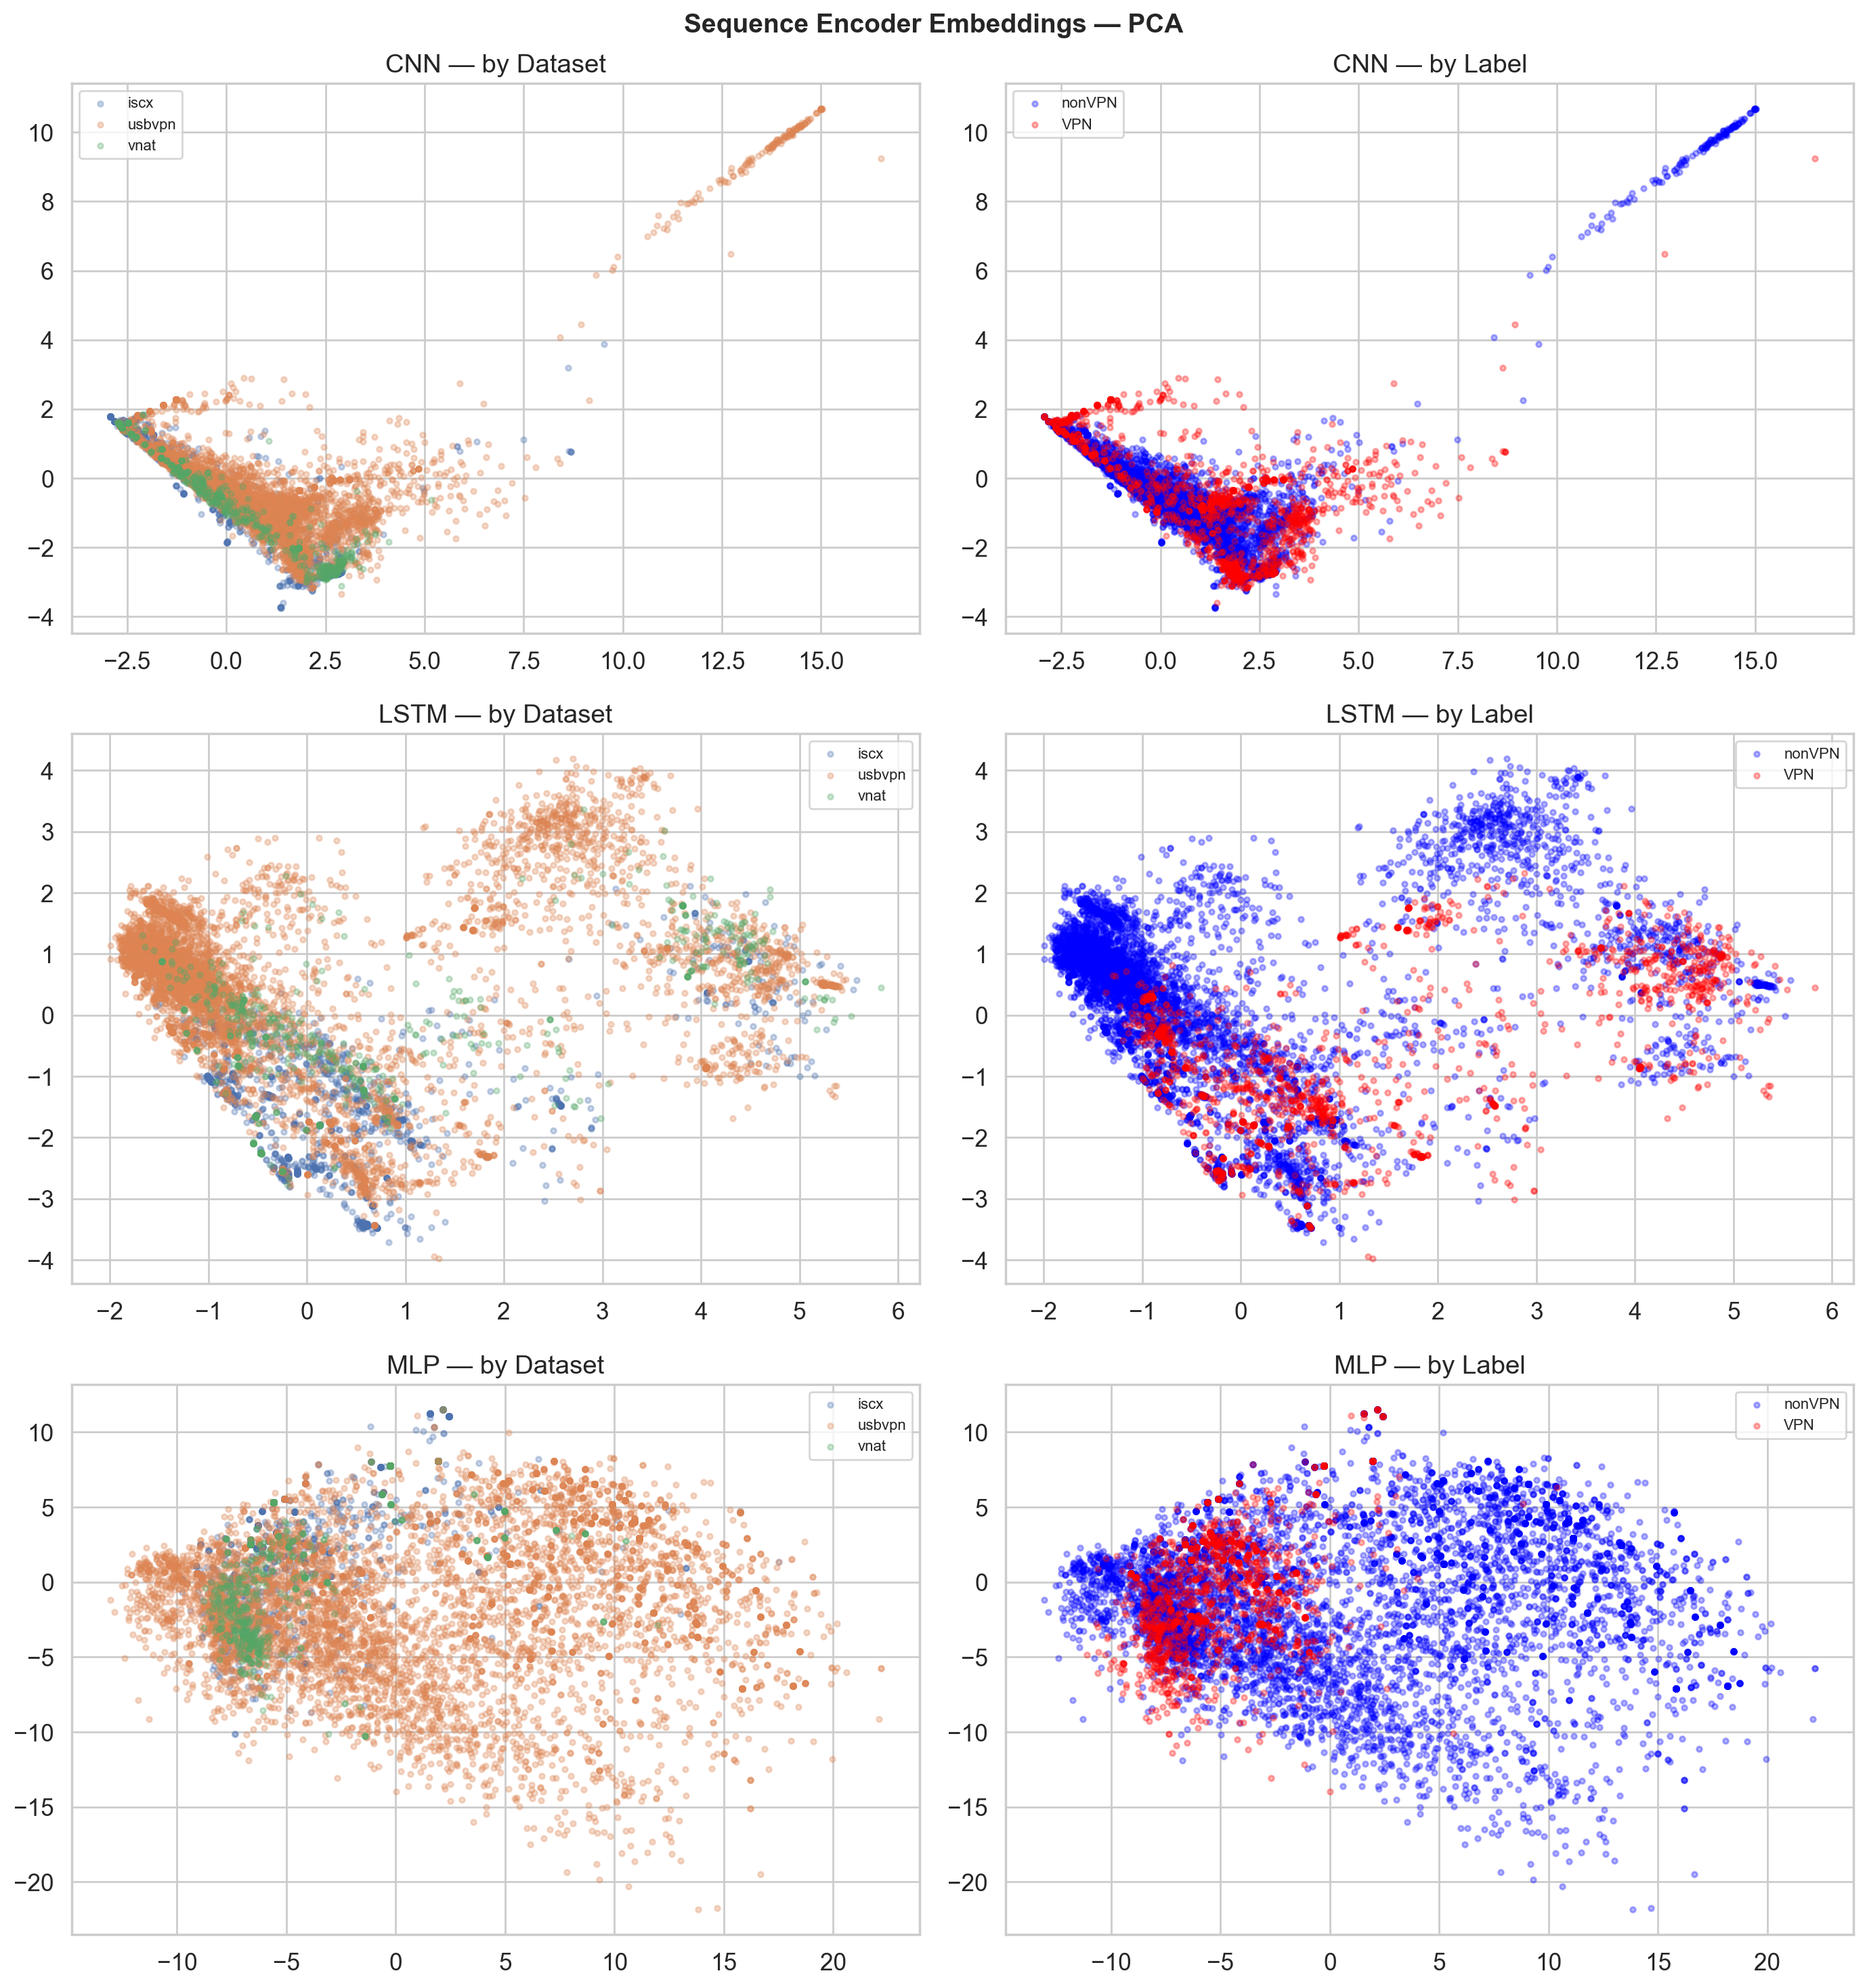


---
### 🖼 Sequence Embedding Umap

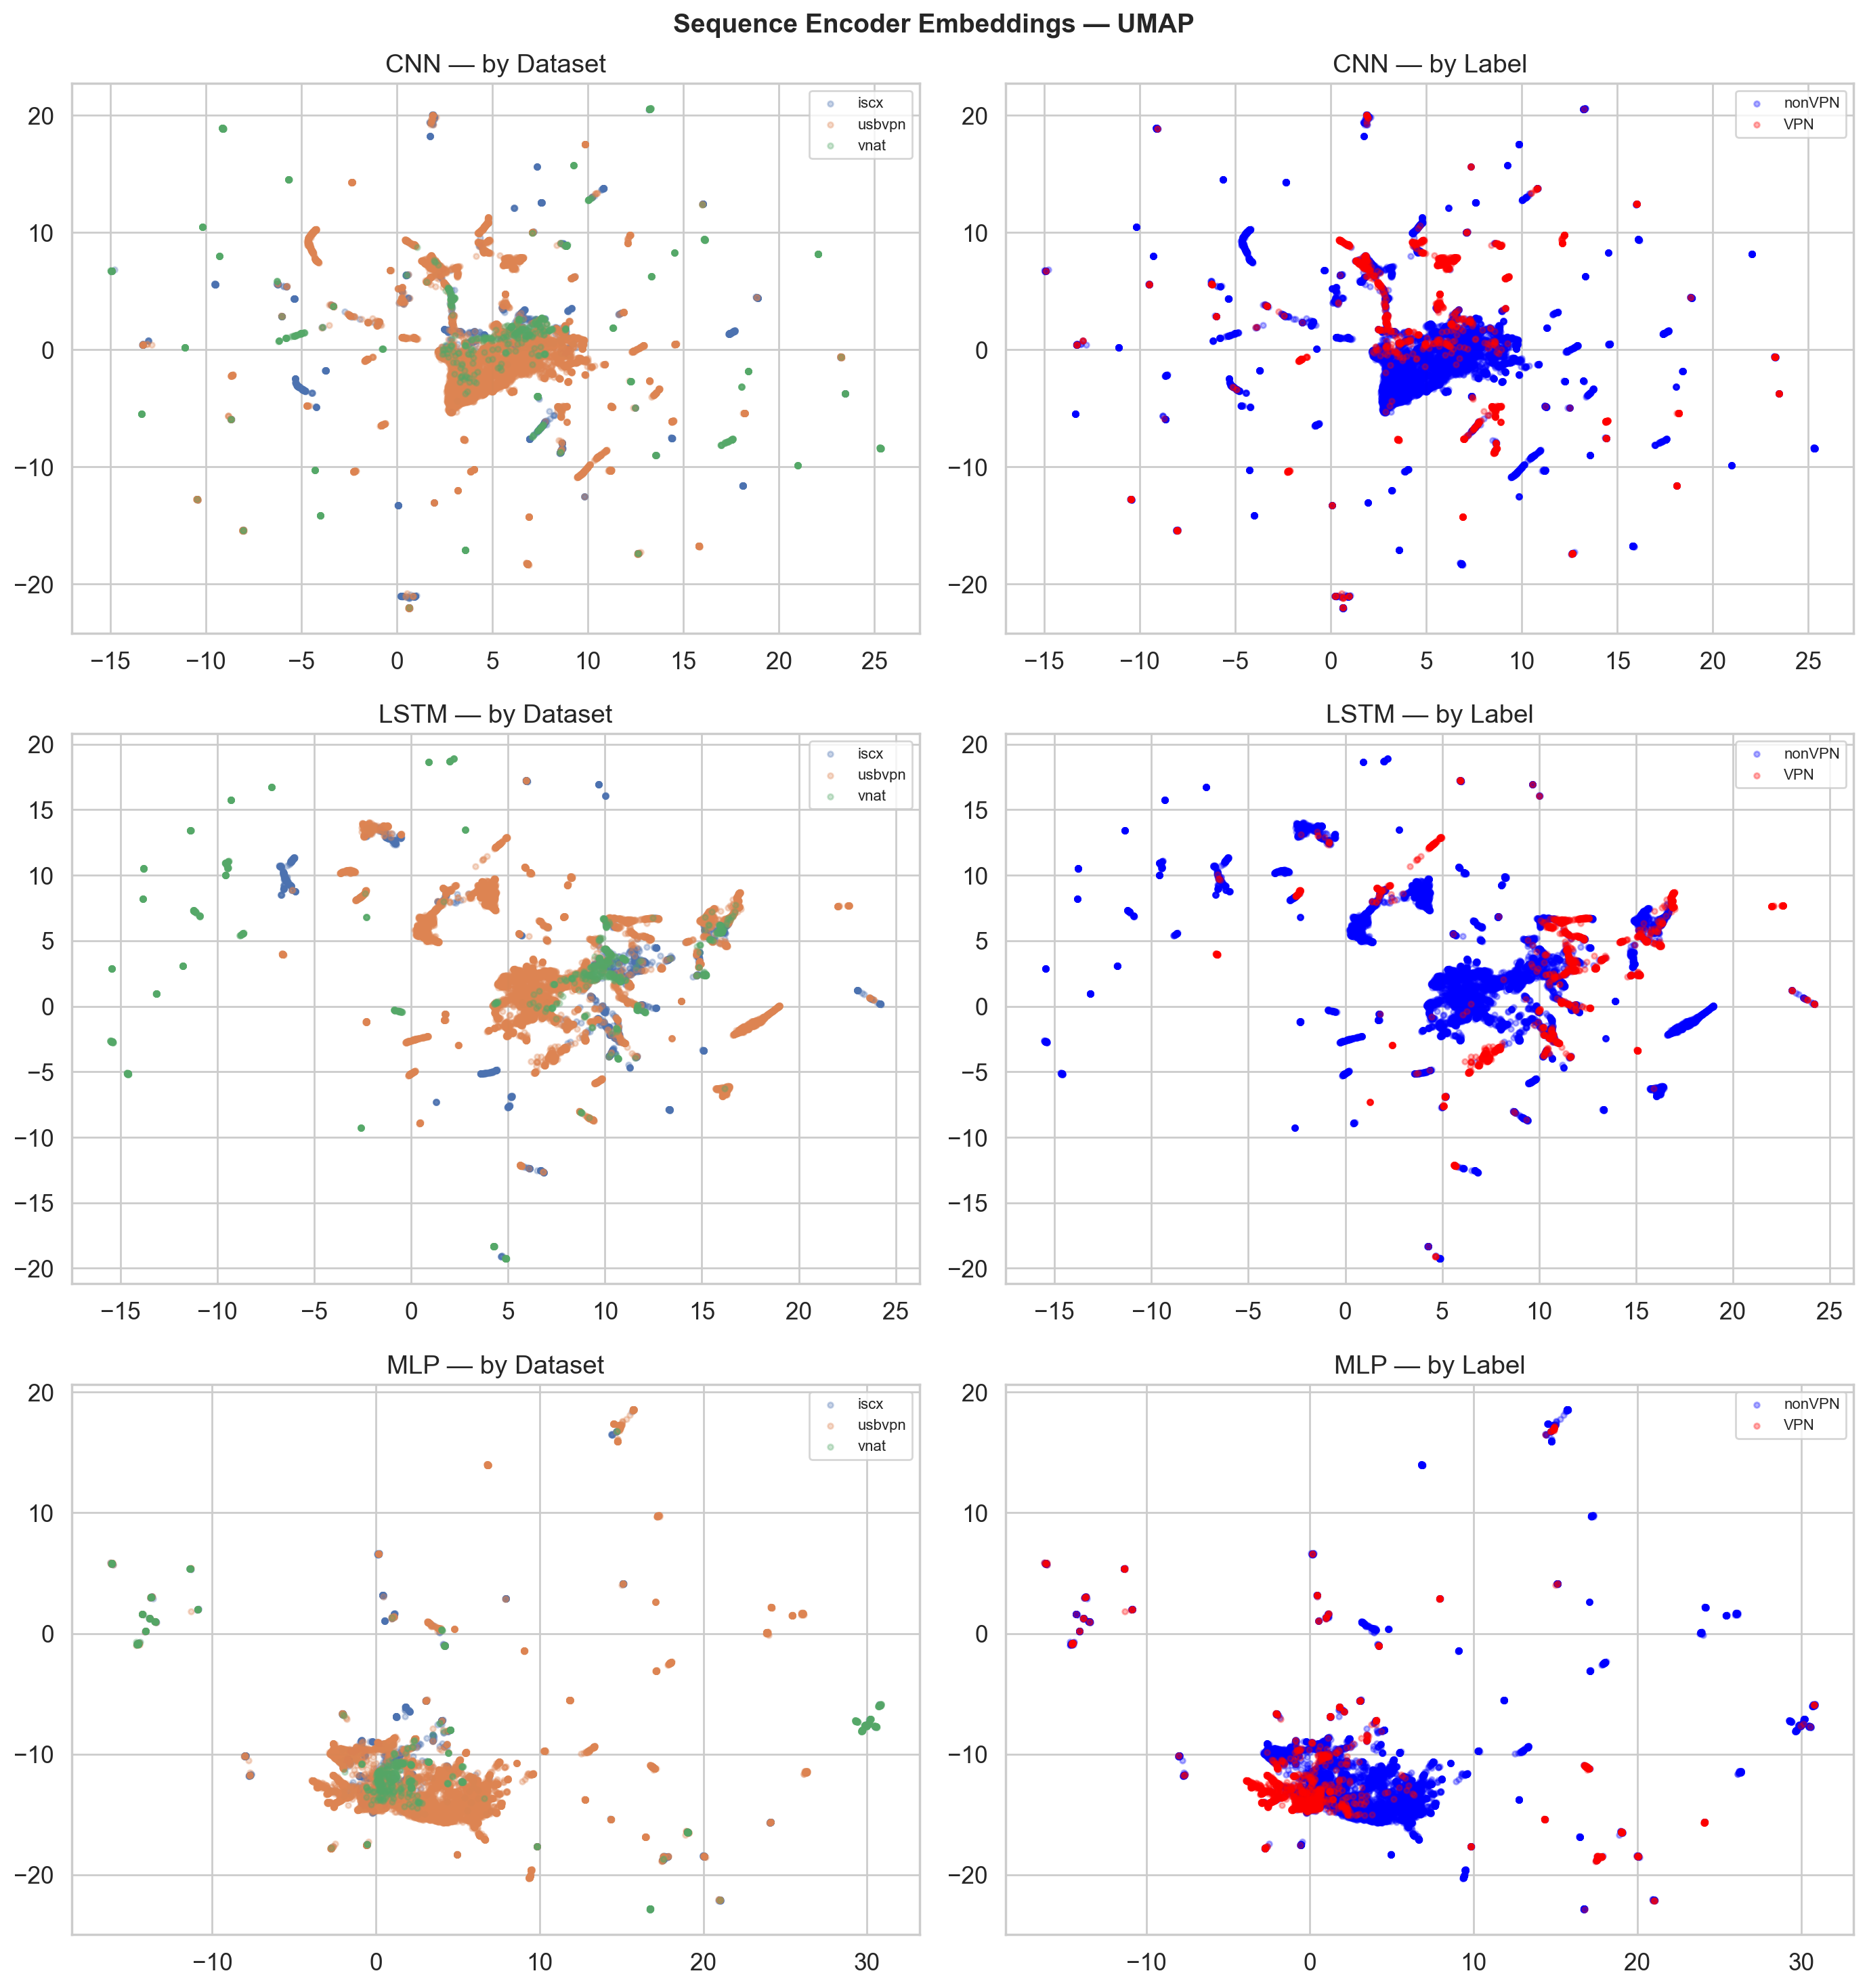


---
### 🖼 Sequence Length Distribution

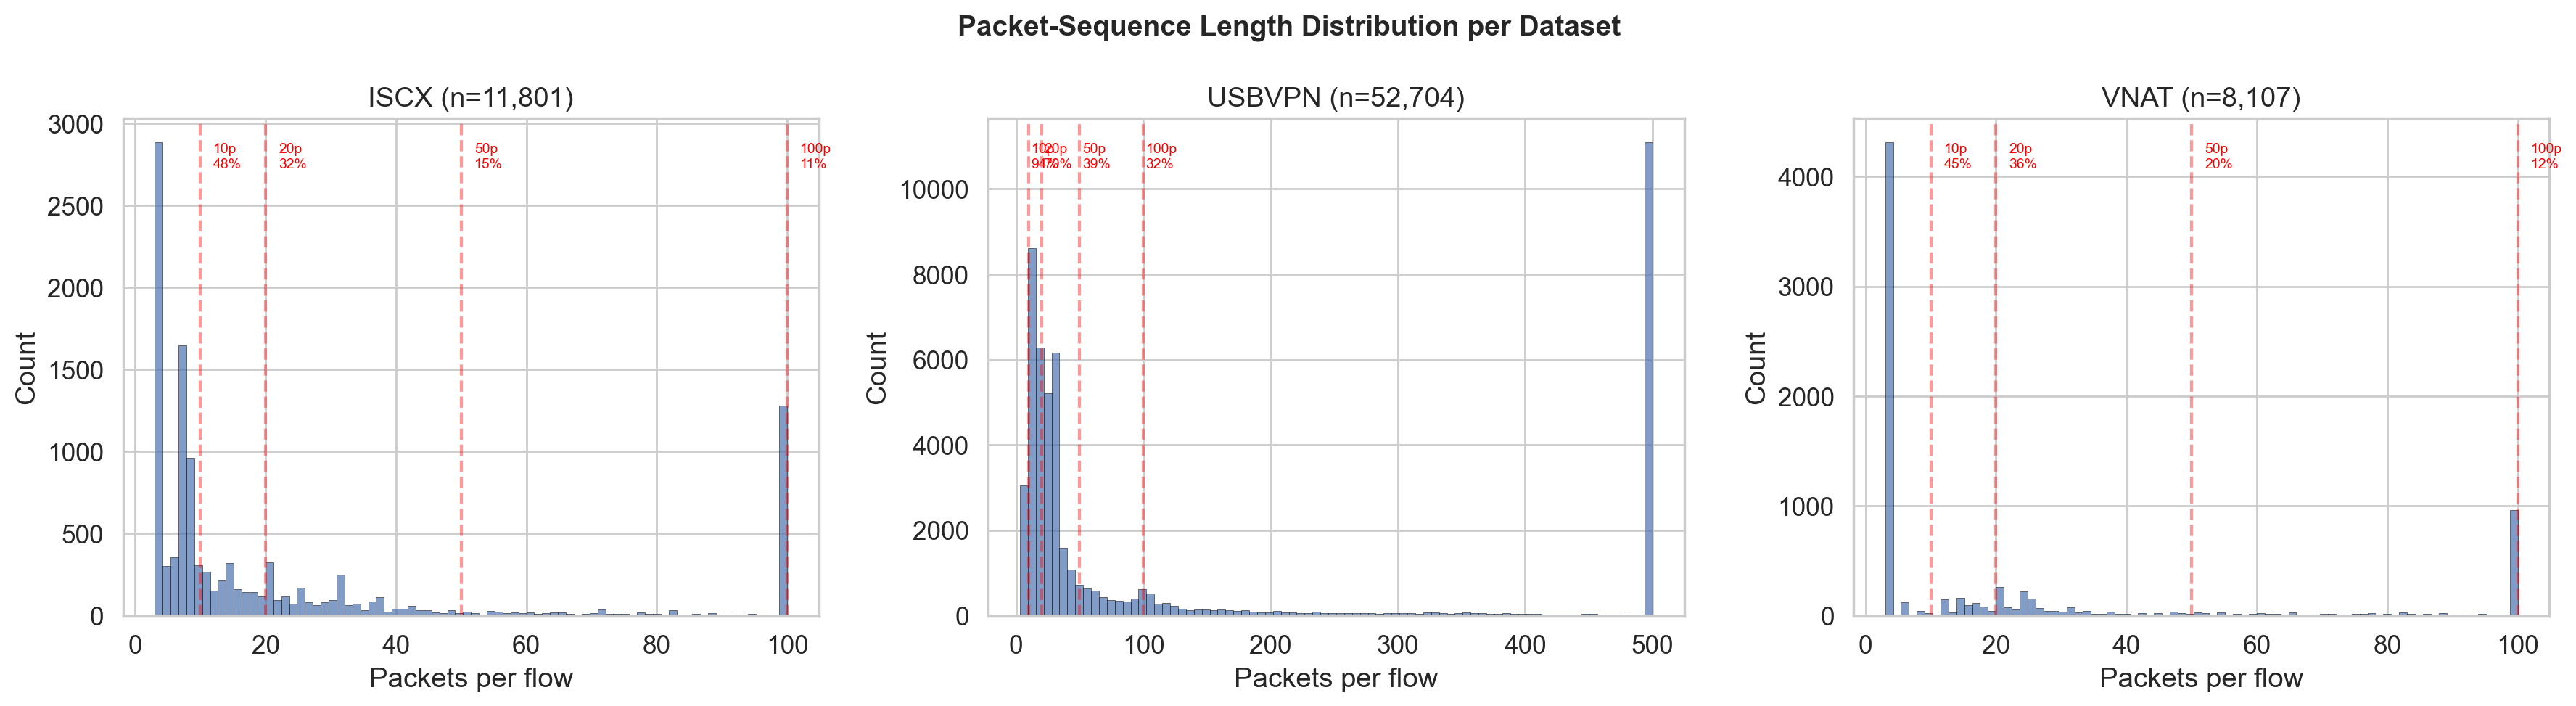


---
### 🖼 Sequence Length Transfer Curve

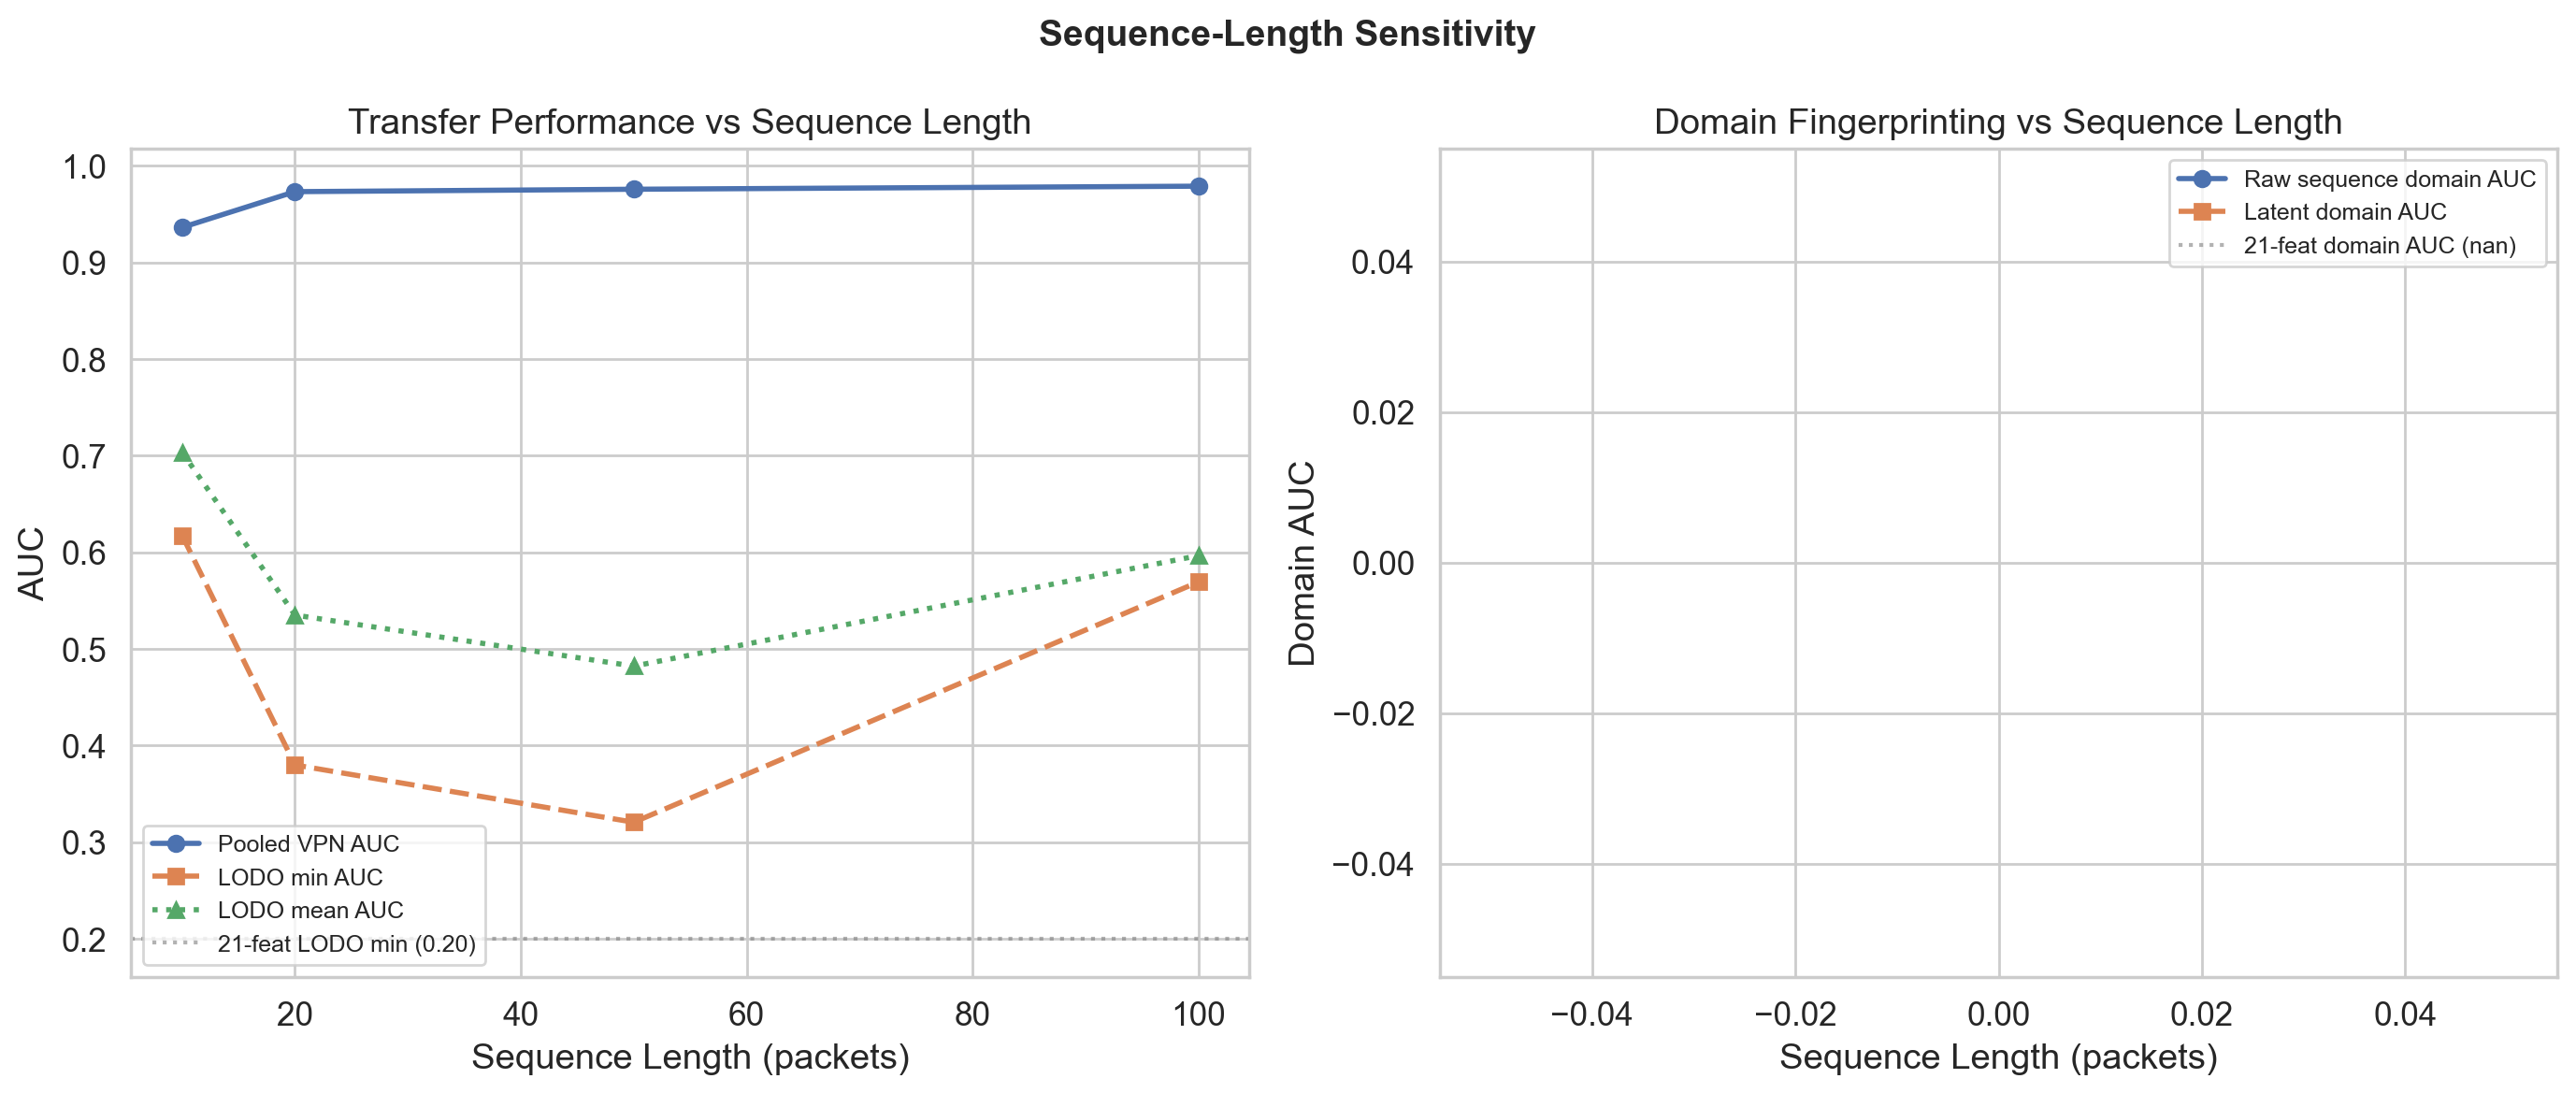


---
### 🖼 Sequence Trajectory Comparison

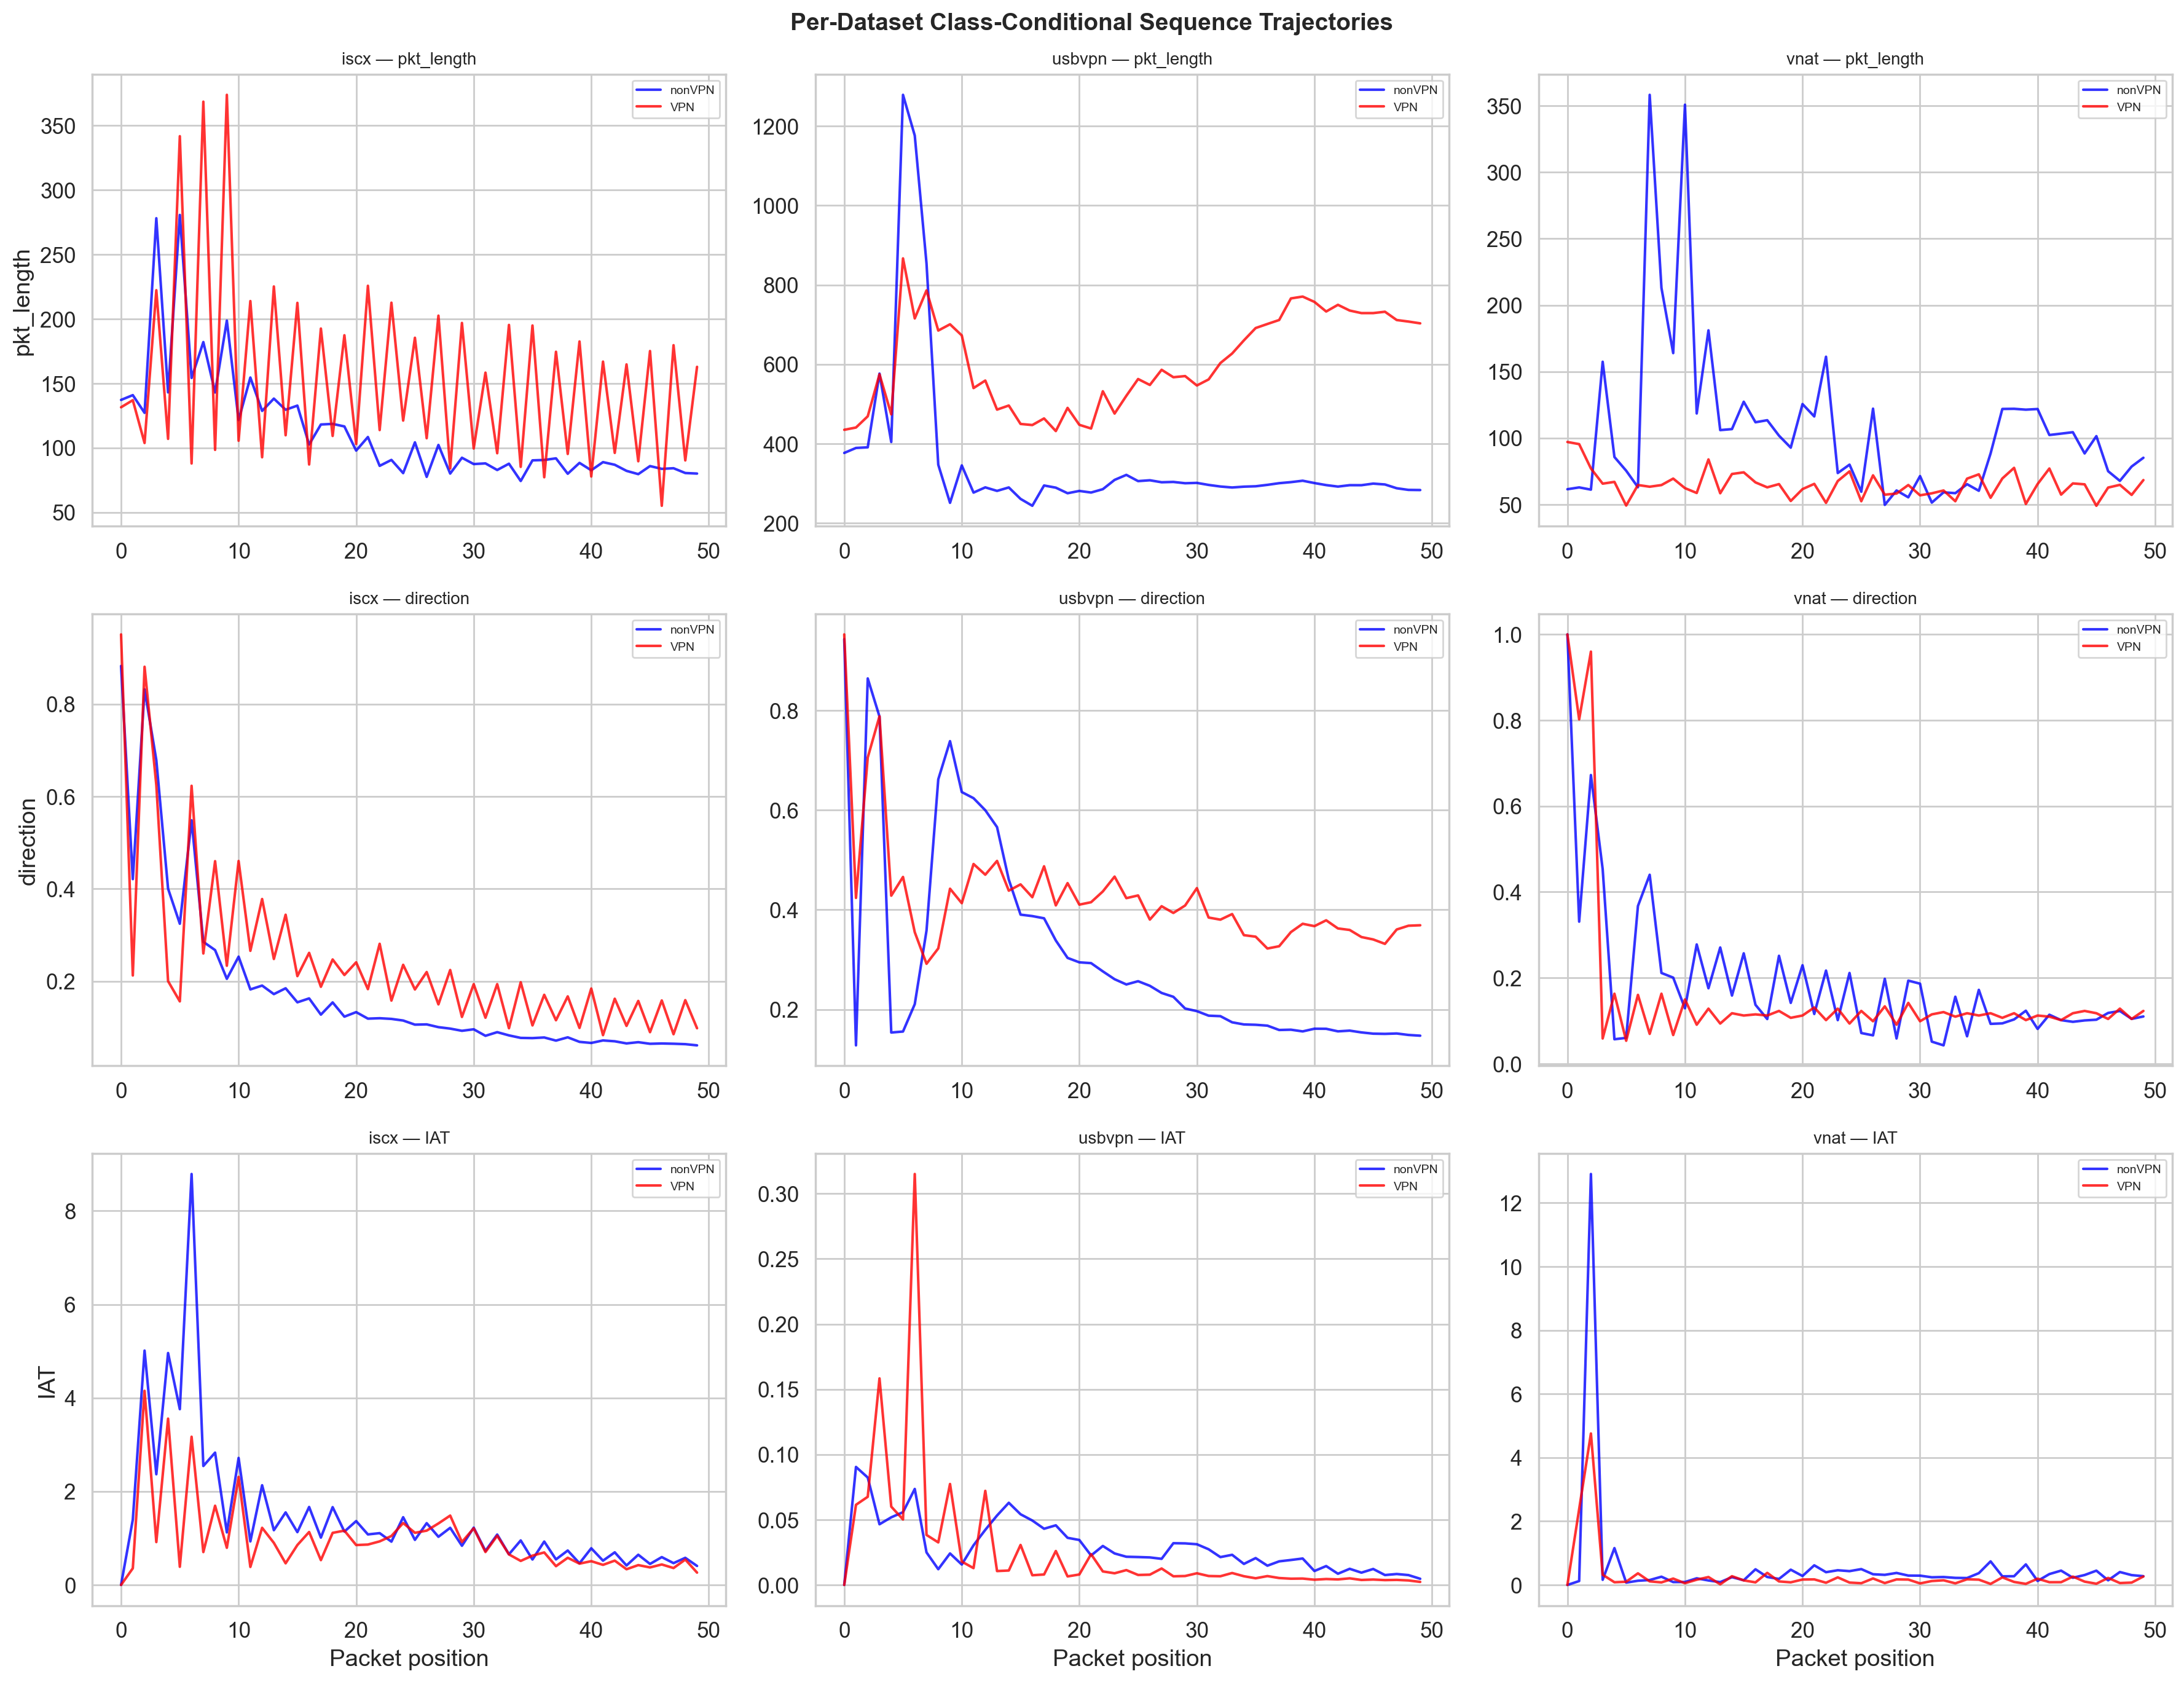


---
# 📋 Key Result Tables


### Sequence Model Results (CNN / LSTM / MLP)

,model,seq_len,channels,pooled_vpn_auc,lodo_min_auc,lodo_mean_auc,worst_recall,worst_fpr
0,CNN,50,all,0.9775,0.5494,0.5765,0.0986,0.1404
1,LSTM,50,all,0.9885,0.2775,0.4526,0.0695,0.2068
2,MLP,50,all,0.9592,0.5001,0.5245,0.0909,0.2005


### Domain Fingerprint AUC (Sequence vs Baseline)

,representation,domain_auc
0,21-feature flow statistics,N/A
1,"raw sequence (len=50, flattened)",N/A


...

### Sequence-Length Sweep
*⚠ `sequence_length_sweep.csv` not found — run the corresponding section first.*

### Channel Ablation

,channels,description,n_channels,pooled_vpn_auc,lodo_min_auc,lodo_mean_auc,domain_auc
0,length,Packet length only,1,0.9914,0.4234,0.4462,N/A
1,direction,Direction only,1,0.9234,0.4763,0.6391,N/A
2,iat,IAT only,1,0.9209,0.1670,0.3256,N/A
3,length_dir,Length + Direction,2,0.9747,0.4413,0.6206,N/A
4,length_iat,Length + IAT,2,0.9944,0.3854,0.6130,N/A
5,dir_iat,Direction + IAT,2,0.9435,0.6593,0.7037,N/A
6,all,All channels,5,0.9756,0.3207,0.4823,N/A



---
# 🏁 Final Verdict

| Key | Value |
|-----|-------|
| **Overall Verdict** | `PARTIAL_IMPROVEMENT` |
| **Best Sequence Model** | CNN |
| **Baseline LODO min AUC** | 0.2 |
| **Best Sequence LODO min** | 0.5494196446210889 |
| **Best Sequence Pooled AUC** | 0.9775454860218435 |
| **Domain Fingerprint Reduced?** | False |
| **LODO Improved?** | True |
| **Best Channel Combo** | dir_iat |

### Thesis Implication
> Sequence models improve LODO transfer but do not eliminate domain fingerprinting. This suggests the problem is partially representational and partially structural.



✅ Gallery complete — all figures and tables displayed above.


In [4]:
# ── Display all generated figures and key tables ─────────────────────
import json, warnings
from pathlib import Path
from IPython.display import display, Image, Markdown
import pandas as pd

warnings.filterwarnings("ignore")

if "OUT" not in dir():
    ROOT = Path.cwd()
    if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
        ROOT = ROOT.parent
    OUT = ROOT / "artifacts" / "thesis_finalization" / "nb54_packet_sequence_representation"

# ── 1. All PNG figures ────────────────────────────────────────────────
_pngs = sorted(OUT.glob("*.png"))
display(Markdown(f"# 📊 NB54 Results Gallery — {len(_pngs)} figures, artifacts dir: `{OUT.name}/`"))

for png_path in _pngs:
    display(Markdown(f"\n---\n### 🖼 {png_path.stem.replace('_', ' ').title()}"))
    display(Image(filename=str(png_path), width=900))

# ── 2. Key result tables ─────────────────────────────────────────────
display(Markdown("\n---\n# 📋 Key Result Tables\n"))

_tables = {
    "Sequence Model Results (CNN / LSTM / MLP)": "sequence_model_results.csv",
    "Domain Fingerprint AUC (Sequence vs Baseline)": "sequence_domain_fingerprint_auc.csv",
    "Latent Representation Domain AUC": "latent_sequence_domain_auc.csv",
    "Representation Transfer Comparison": "representation_transfer_comparison.csv",
    "Sequence-Length Sweep": "sequence_length_sweep.csv",
    "Channel Ablation": "sequence_channel_ablation.csv",
}

for title, fname in _tables.items():
    csv_path = OUT / fname
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        display(Markdown(f"### {title}"))
        # Round floats for readability
        for col in df.select_dtypes(include="float").columns:
            df[col] = df[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
        display(df)
    else:
        display(Markdown(f"### {title}\n*⚠ `{fname}` not found — run the corresponding section first.*"))

# ── 3. Final verdict summary ─────────────────────────────────────────
verdict_path = OUT / "packet_sequence_final_verdict.json"
if verdict_path.exists():
    verdict = json.loads(verdict_path.read_text(encoding="utf-8"))
    display(Markdown(f"""
---
# 🏁 Final Verdict

| Key | Value |
|-----|-------|
| **Overall Verdict** | `{verdict.get('overall_verdict', 'N/A')}` |
| **Best Sequence Model** | {verdict.get('best_sequence_model', 'N/A')} |
| **Baseline LODO min AUC** | {verdict.get('baseline_lodo_min_auc', 'N/A')} |
| **Best Sequence LODO min** | {verdict.get('best_sequence_lodo_min', 'N/A')} |
| **Best Sequence Pooled AUC** | {verdict.get('best_sequence_pooled_auc', 'N/A')} |
| **Domain Fingerprint Reduced?** | {verdict.get('domain_fingerprint_reduced', 'N/A')} |
| **LODO Improved?** | {verdict.get('lodo_improved_over_baseline', 'N/A')} |
| **Best Channel Combo** | {verdict.get('best_channel_combination', 'N/A')} |

### Thesis Implication
> {verdict.get('thesis_implication', 'N/A')}
"""))
else:
    display(Markdown("*⚠ Final verdict JSON not found — run Section 11 first.*"))

print("\n✅ Gallery complete — all figures and tables displayed above.")
